In [ ]:
import os

sample_dir = f'/content/drive/MyDrive/Saved_from_Chrome'
print("Files found:")
for f in os.listdir(sample_dir):
    print(" -", f)

Files found:
 - CBC-sample-report-with-notes_0.pdf
 - CBC Test Report.pdf
 - page1_preview.png


In [ ]:
# Install core libraries initially, letting pip resolve dependencies. We will explicitly manage Pillow later due to conflicts.
!pip install easyocr pdfplumber pdf2image -q
!pip install Pillow==8.4.0 -q

# Uninstall current Pillow to ensure clean installation of a specific version.
!pip uninstall -y Pillow

# Install Pillow to a version compatible with pdf2image and other libraries.
# This version (10.1.0) addresses compatibility for pdf2image and scikit-image.
# Note: This will break easyocr due to its older Pillow dependency (< 9.0.0).
!pip install Pillow==10.1.0 -q

# Ensure poppler-utils is installed for pdf2image to work
!apt-get install poppler-utils -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdfplumber 0.11.10 requires Pillow>=12.2.0, but you have pillow 8.4.0 which is incompatible.
torchtune 0.6.1 requires Pillow>=9.4.0, but you have pillow 8.4.0 which is incompatible.
fastai 2.8.7 requires pillow>=9.0.0, but you have pillow 8.4.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 8.4.0 which is incompatible.
Found existing installation: Pillow 8.4.0
Uninstalling Pillow-8.4.0:
  Successfully uninstalled Pillow-8.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdfplumber 0.11.10 requires Pillow>=12.2.0, but you have pillow 10.1.0 which is incompatible.
Reading package lists...
Building dependency tree...
Reading state information...
poppl

In [ ]:
import pdfplumber

def try_direct_text_extraction(pdf_path):
    """Attempt to pull text directly from the PDF (works if it's not a scanned image)."""
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text.strip()

pdf_path = f"{sample_dir}/CBC-sample-report-with-notes_0.pdf"
direct_text = try_direct_text_extraction(pdf_path)

print(f"Characters extracted: {len(direct_text)}")
print("---PREVIEW---")
print(direct_text[:500])

Characters extracted: 5027
---PREVIEW---
THE COMPLETE BLOOD COUNT SAMPLE REPORT 1. Name and address of the lab where the test was performed.
Tests may be run in a physician office lab, a lab located in a
Different laboratories gener T at h e e r e C p o o m rts p t le ha te t c B a l n o v o a d ry C g o re u a n t t ly S in a m ap p p l e e a R ra e n p c o e r a t n d in the order and kind of clinic or hospital, and/or samples may be sent to a reference
information included. This is one example of what a lab report for a Complete Blo


In [ ]:
with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[0]
    layout_text = page.extract_text(layout=True)

print(layout_text[:1500])


                                                                                                                                   
                                                                                                                                   
                                                                                                                                   
                                                                                                                                   
                      THE COMPLETE  BLOOD  COUNT  SAMPLE  REPORT                      1. Name and address of the lab where the test was performed.
                                                                                                                                   
                                                                                         Tests may be run in a physician office lab, a lab located in a
       Different laboratories gener T at 

In [ ]:
!apt-get install -y poppler-utils
!apt-get update -qq
!apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.13).
0 upgraded, 0 newly installed, 0 to remove and 109 not upgraded.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.13).
0 upgraded, 0 newly installed, 0 to remove and 109 not upgraded.


In [ ]:
!which pdftoppm

/usr/bin/pdftoppm


In [ ]:
!pip install "Pillow==11.3.0" -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdfplumber 0.11.10 requires Pillow>=12.2.0, but you have pillow 11.3.0 which is incompatible.


In [ ]:
!pip install -U easyocr pdf2image pdfplumber -q

In [ ]:
from pdf2image import convert_from_path

images = convert_from_path(pdf_path, dpi=200)
print(f"Number of pages converted: {len(images)}")

images[0].save(f"/content/drive/MyDrive/Saved_from_Chrome/page1_preview.png")
print("Saved preview image")

Number of pages converted: 1
Saved preview image


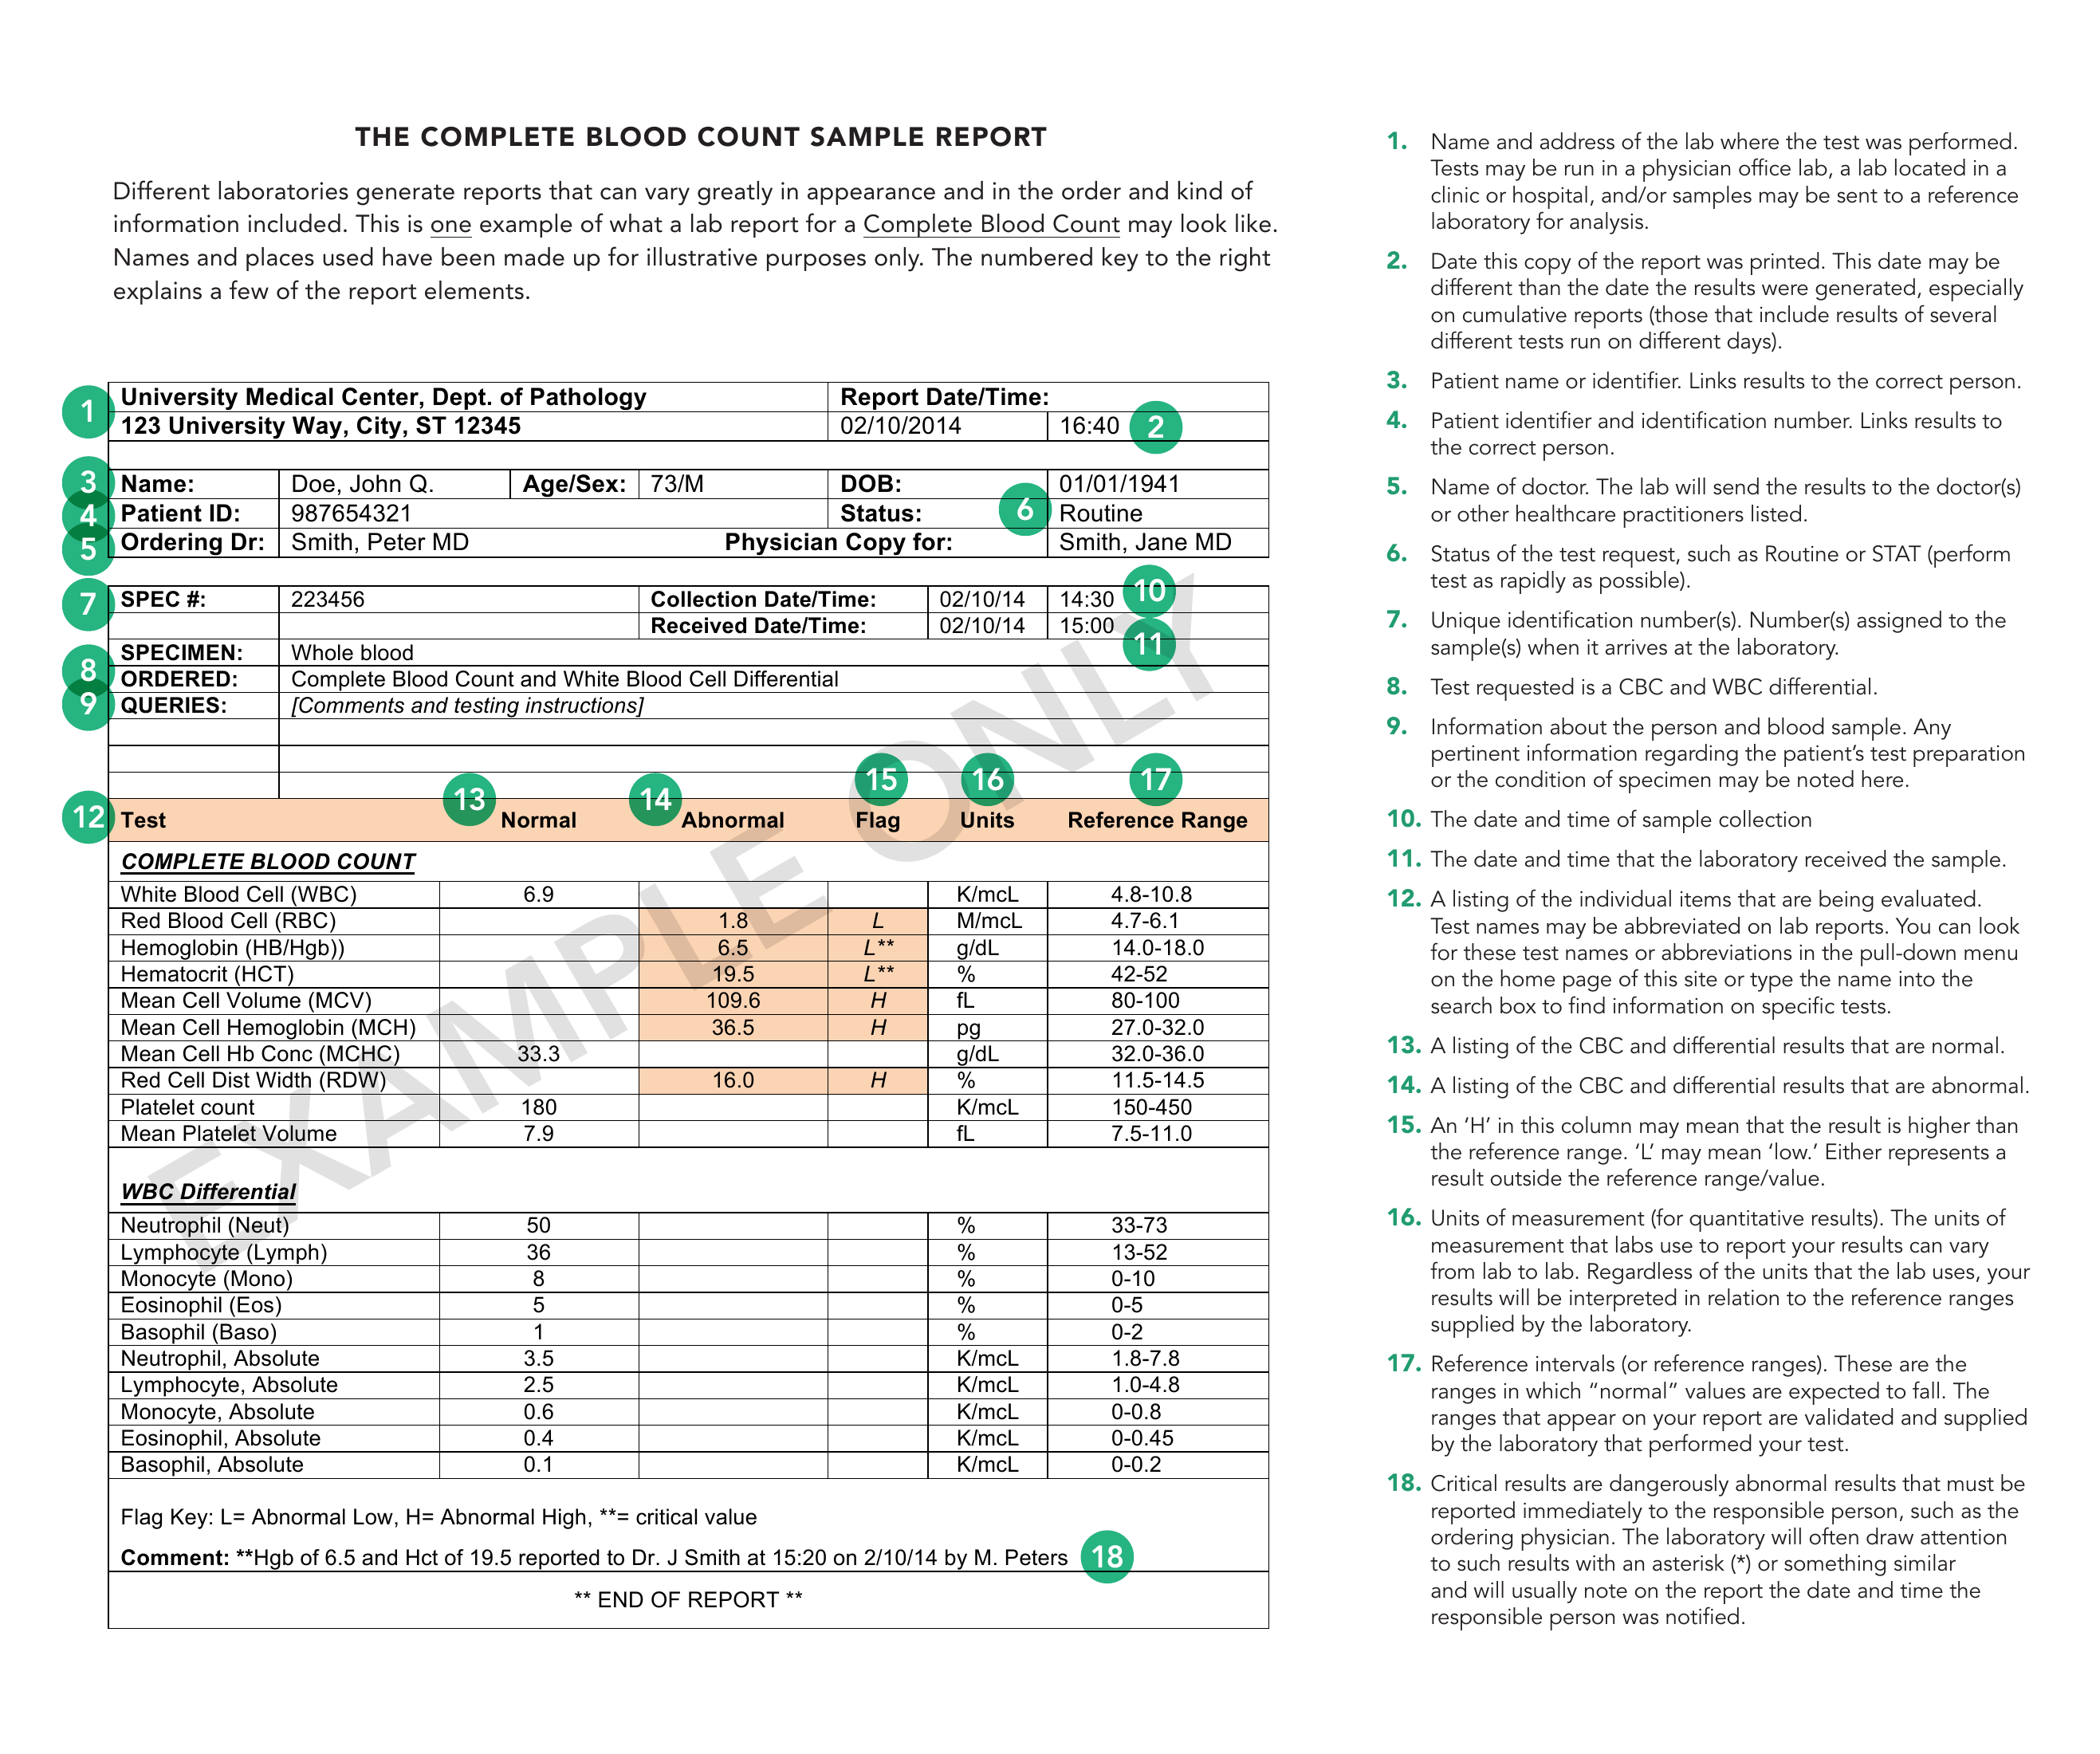

In [ ]:
from IPython.display import Image, display
display(Image(f"/content/drive/MyDrive/Saved_from_Chrome/page1_preview.png"))

In [ ]:
!pip install -U easyocr -q

In [ ]:
import easyocr

# Initialize the OCR reader (English language model)
# gpu=True will use Colab's GPU if available, making it much faster
reader = easyocr.Reader(['en'], gpu=True)
print("OCR reader ready")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR reader ready


In [ ]:
results = reader.readtext(f"/content/drive/MyDrive/Saved_from_Chrome/page1_preview.png")

print(f"Number of text regions detected: {len(results)}")
print("---FIRST 10 DETECTED TEXT BLOCKS---")
for (bbox, text, confidence) in results[:10]:
    print(f"'{text}'  (confidence: {confidence:.2f})")

Number of text regions detected: 236
---FIRST 10 DETECTED TEXT BLOCKS---
'THE COMPLETE BLOOD COUNT SAMPLE REPORT'  (confidence: 0.88)
'1.'  (confidence: 0.99)
'Name and address of the lab where the test was performed:'  (confidence: 0.73)
'Tests may be run in a physician office lab, a lab located in a'  (confidence: 0.83)
'Different laboratories generate reports that can vary greatly in appearance and in the order and kind of'  (confidence: 0.85)
'clinic or hospital, and/or samples may be sent to a reference'  (confidence: 0.73)
'information included: This is one example of what a lab report for a Complete Blood Count may look like'  (confidence: 0.65)
'laboratory for analysis.'  (confidence: 0.68)
'Names and places used have been made up for illustrative purposes only: The numbered'  (confidence: 0.72)
'to the right'  (confidence: 0.96)


In [ ]:
# Combine all detected text into one block, keep only confident results
full_text = ""
low_confidence_count = 0

for (bbox, text, confidence) in results:
    if confidence >= 0.4:  # filter out very unreliable detections
        full_text += text + " "
    else:
        low_confidence_count += 1

print(f"Low-confidence blocks filtered out: {low_confidence_count}")
print("---FULL EXTRACTED TEXT---")
print(full_text)

Low-confidence blocks filtered out: 3
---FULL EXTRACTED TEXT---
THE COMPLETE BLOOD COUNT SAMPLE REPORT 1. Name and address of the lab where the test was performed: Tests may be run in a physician office lab, a lab located in a Different laboratories generate reports that can vary greatly in appearance and in the order and kind of clinic or hospital, and/or samples may be sent to a reference information included: This is one example of what a lab report for a Complete Blood Count may look like laboratory for analysis. Names and places used have been made up for illustrative purposes only: The numbered to the right 2. Date this copy of the report was printed. This date may be explains a few of the report elements. different than the date the results were generated, especially on cumulative reports (those that include results of several different tests run on different days): 3. Patient name or identifier Links results to the correct person: University Medical Center, Dept, of Pathology R

In [ ]:
import os

# Where your source PDFs actually live
sample_dir = '/content/drive/MyDrive/Saved_from_Chrome'

# Where we'll save our own generated files (OCR text, previews, etc.)
# Separate from sample_dir since these are outputs, not source files
project_path = '/content/drive/MyDrive/Medical_Report_Analyzer'
os.makedirs(f'{project_path}/outputs', exist_ok=True)

print("Sample PDFs folder:", sample_dir)
print("Project outputs folder:", f'{project_path}/outputs')
print()
print("Files in sample_dir:")
print(os.listdir(sample_dir))

Sample PDFs folder: /content/drive/MyDrive/Saved_from_Chrome
Project outputs folder: /content/drive/MyDrive/Medical_Report_Analyzer/outputs

Files in sample_dir:
['CBC-sample-report-with-notes_0.pdf', 'CBC Test Report.pdf', 'page1_preview.png']


In [ ]:
pdf_path = f"{sample_dir}/CBC-sample-report-with-notes_0.pdf"
print(pdf_path)

/content/drive/MyDrive/Saved_from_Chrome/CBC-sample-report-with-notes_0.pdf


In [ ]:
output_text_path = f"{project_path}/outputs/report_1_ocr_raw.txt"

with open(output_text_path, "w", encoding="utf-8") as f:
    f.write(full_text)

print(f"Saved raw OCR text to: {output_text_path}")

Saved raw OCR text to: /content/drive/MyDrive/Medical_Report_Analyzer/outputs/report_1_ocr_raw.txt


For report **2**

In [ ]:
pdf_path_2 = f"{sample_dir}/CBC Test Report.pdf"
print(pdf_path_2)

/content/drive/MyDrive/Saved_from_Chrome/CBC Test Report.pdf


In [ ]:
!pip install pdf2image -q

from pdf2image import convert_from_path

images_2 = convert_from_path(pdf_path_2, dpi=200)
print(f"Number of pages converted: {len(images_2)}")

images_2[0].save(f"{project_path}/outputs/page2_preview.png")
print("Saved preview image")

Number of pages converted: 1
Saved preview image


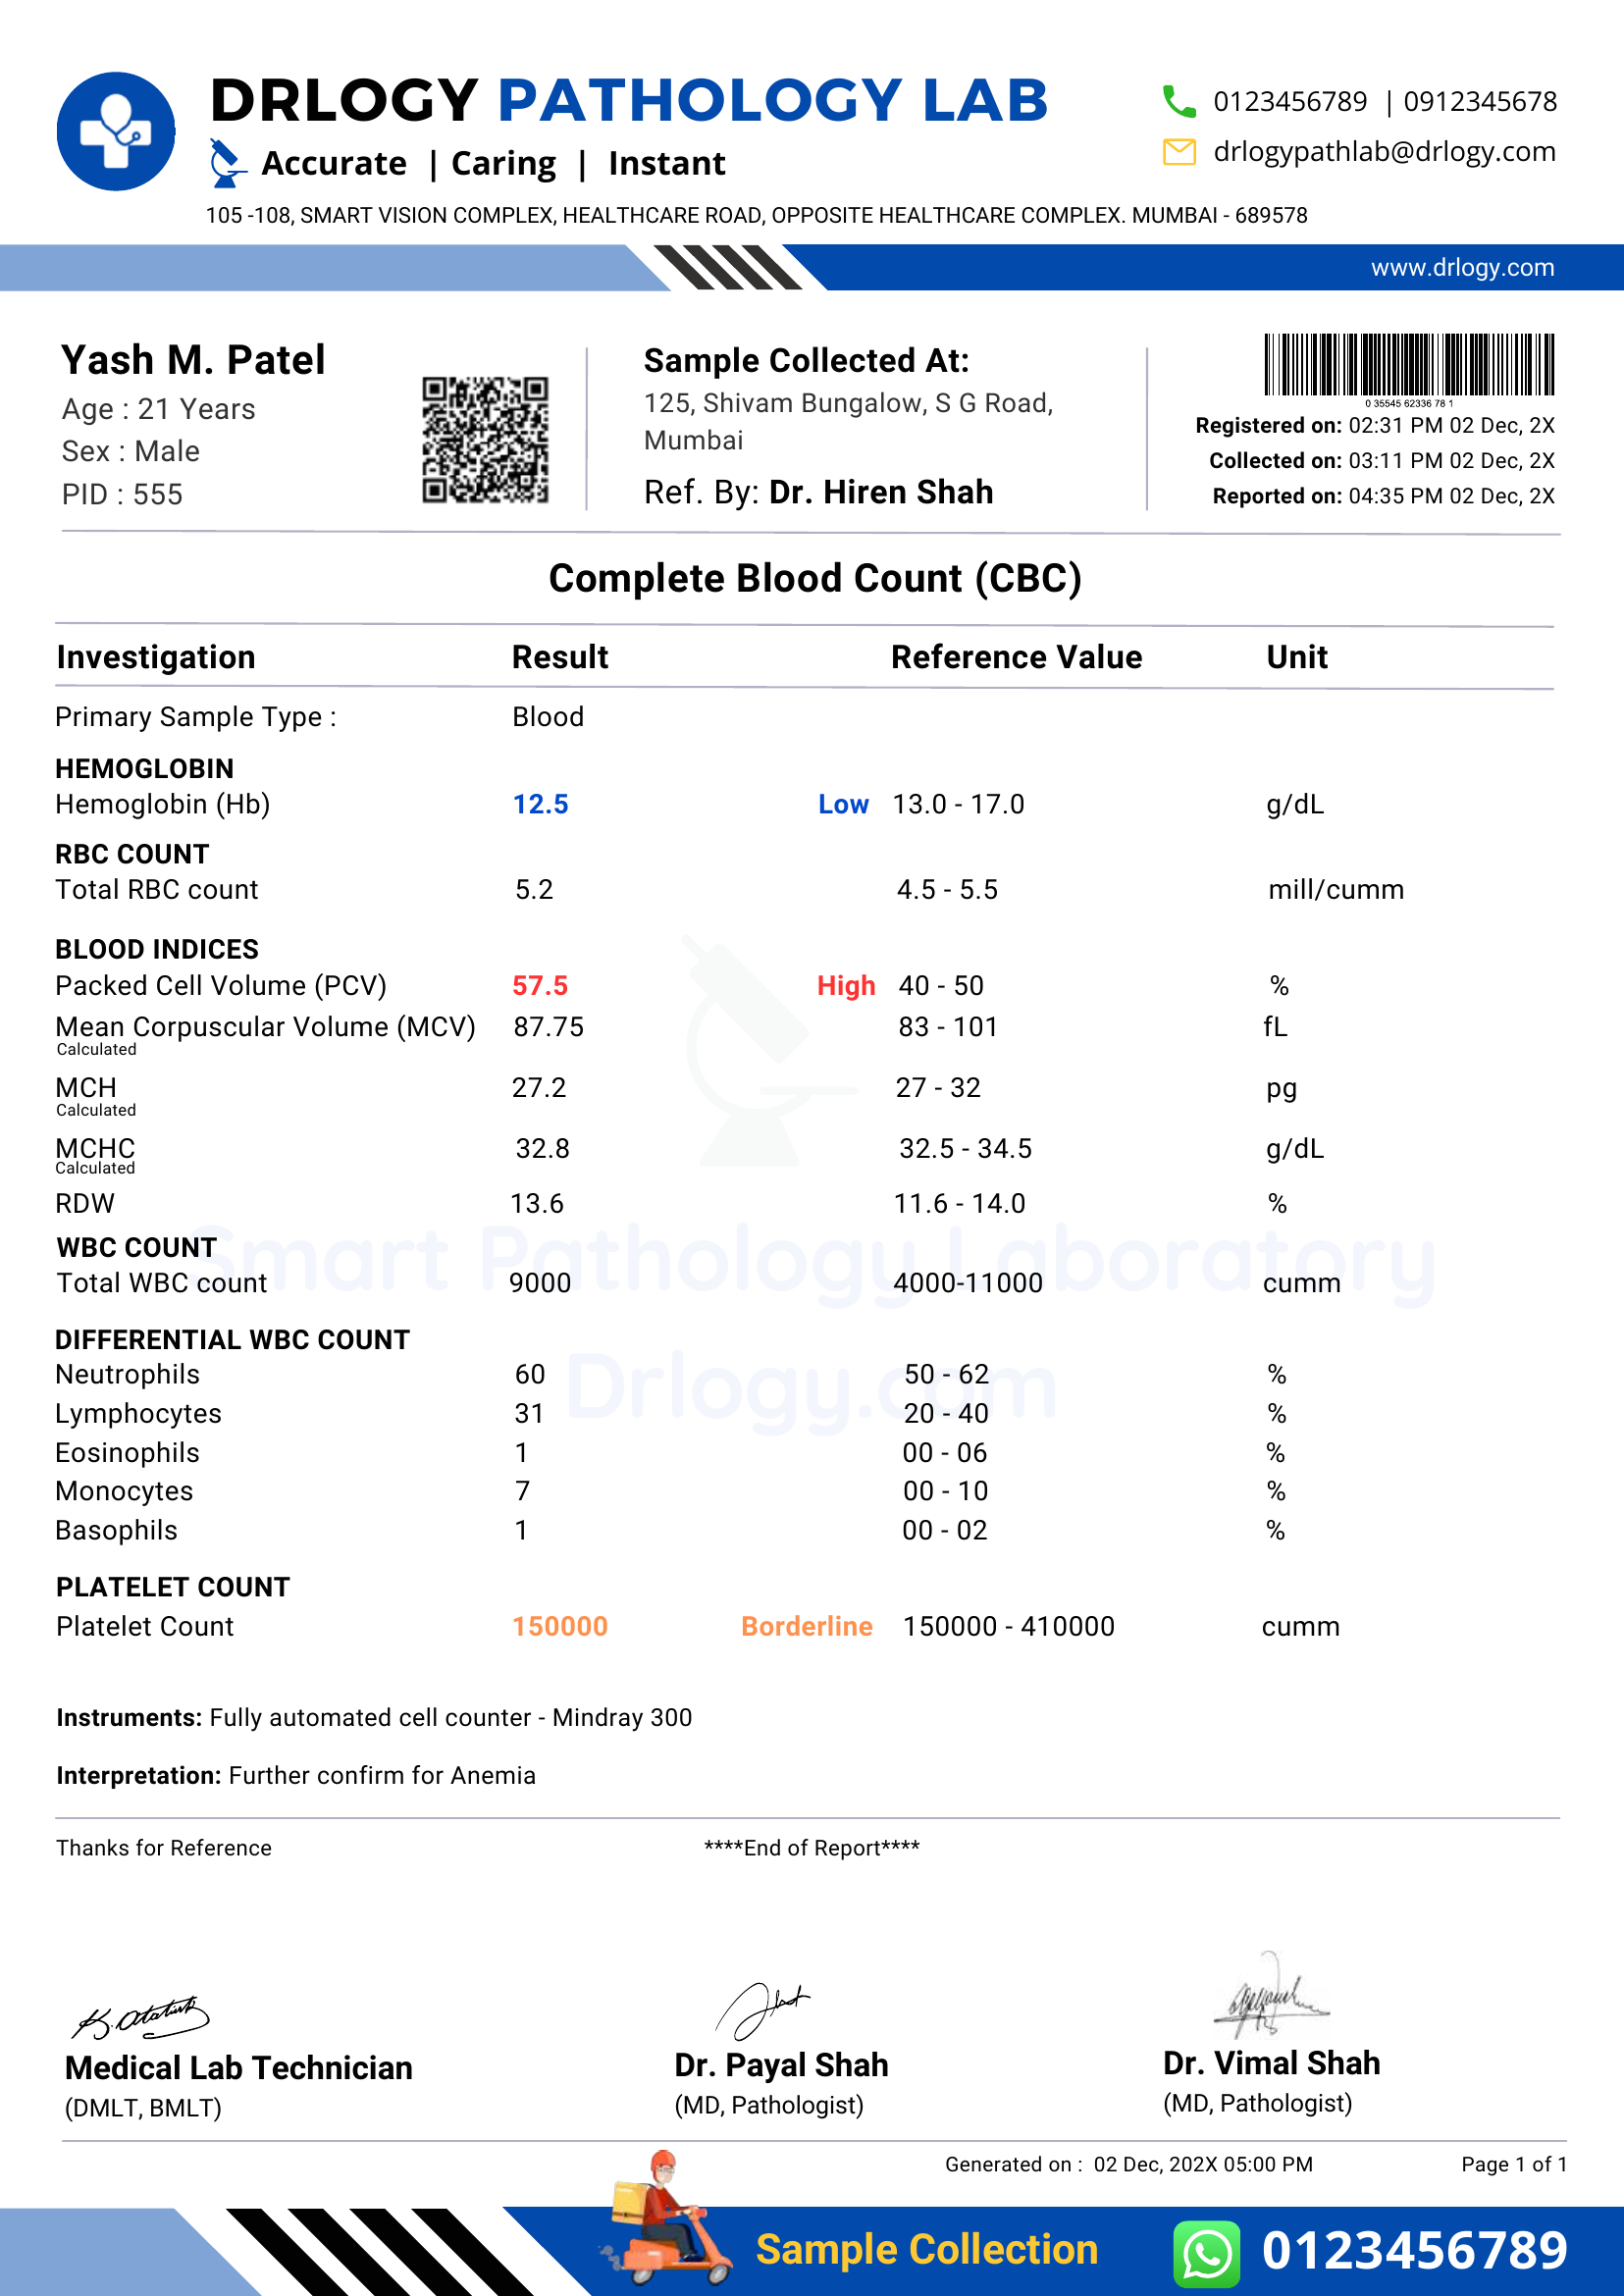

In [ ]:
from IPython.display import Image, display
display(Image(f"{project_path}/outputs/page2_preview.png"))

In [ ]:
results_2 = reader.readtext(f"{project_path}/outputs/page2_preview.png")
print(f"Number of text regions detected: {len(results_2)}")

Number of text regions detected: 128


In [ ]:
full_text_2 = ""
low_confidence_count_2 = 0

for (bbox, text, confidence) in results_2:
    if confidence >= 0.4:
        full_text_2 += text + " "
    else:
        low_confidence_count_2 += 1

print(f"Low-confidence blocks filtered out: {low_confidence_count_2}")
print("---FULL EXTRACTED TEXT---")
print(full_text_2)

Low-confidence blocks filtered out: 7
---FULL EXTRACTED TEXT---
DRLOGY PATHOLOGY LAB 0123456789 0912345678 Accurate Caring Instant drlogypathlab@drlogy.com 105 -108, SMART VISION COMPLEX, HEALTHCARE ROAD, OPPOSITE HEALTHCARE COMPLEX. MUMBAI - 689578 WWW drlogy com Yash M. Patel Sample Collected At: Age : 21 Years 125, Shivam Bungalow, S G Road, Registered on: 02.31 PM 02 Dec, 2X Sex Male Mumbai Collected on: 03.11 PM 02 Dec, 2X PID 555 Ref. By: Dr. Hiren Shah Reported on: 04.35 PM 02 Dec, 2X Complete Blood Count (CBC) Investigation Result Reference Value Unit Primary Sample Type Blood HEMOGLOBIN Hemoglobin (Hb) 12.5 Low 13.0 17.0 g/dL RBC COUNT Total RBC count 5.2 4.5 5.5 mill/cumm BLOOD INDICES Packed Cell Volume (PCV) 57.5 High 40 50 % Mean Corpuscular Volume (MCV) 87.75 83 101 fL Calculated MCH 27.2 27 32 pg Calculated MCHC 32.8 32.5 34.5 g/dL Calculated RDW 13.6 11.6 14.0 % WBC COUNT Total WBC 4000-11000 DIFFERENTIAL WBC COUNT Neutrophils 60 50 - 62 % Lymphocytes 31 20 - 40 % Eosin

In [ ]:
output_text_path_2 = f"{project_path}/outputs/report_2_ocr_raw.txt"

with open(output_text_path_2, "w", encoding="utf-8") as f:
    f.write(full_text_2)

print(f"Saved raw OCR text to: {output_text_path_2}")

Saved raw OCR text to: /content/drive/MyDrive/Medical_Report_Analyzer/outputs/report_2_ocr_raw.txt


## Phase 2: Information Extraction
Goal: convert raw OCR text into structured records (Parameter, Value, Unit, Range, Flag)
using a hybrid regex + NER approach. **bold text**

In [ ]:
with open(f"{project_path}/outputs/report_1_ocr_raw.txt", "r", encoding="utf-8") as f:
    text_1 = f.read()

with open(f"{project_path}/outputs/report_2_ocr_raw.txt", "r", encoding="utf-8") as f:
    text_2 = f.read()

print("Report 1 length:", len(text_1))
print("Report 2 length:", len(text_2))

Report 1 length: 4529
Report 2 length: 1375


In [ ]:
import re

# A pattern that finds: a number, followed by a known medical unit
# \d+\.?\d* means: one or more digits, optionally followed by a decimal point and more digits
# This catches both "12.5" and "9000"
unit_pattern = r'(\d+\.?\d*)\s*(g/dL|mg/dL|mill/cumm|K/mcL|KlmcL|M/mcL|MlmcL|fL|pg|cumm|/uL|%)'

matches = re.findall(unit_pattern, text_1)
print(f"Found {len(matches)} number+unit matches in Report 1")
for m in matches[:15]:
    print(m)

Found 14 number+unit matches in Report 1
('6.9', 'KlmcL')
('1.8', 'MlmcL')
('109.6', 'fL')
('180', 'KlmcL')
('7.9', 'fL')
('50', '%')
('36', '%')
('8', '%')
('1', '%')
('3.5', 'KlmcL')
('2.5', 'KlmcL')
('0.6', 'KlmcL')
('0.4', 'KlmcL')
('0', 'KlmcL')


In [ ]:
# Search for Hemoglobin and Basophil context in the raw text
import re

for keyword in ["Hemoglobin", "MCH", "RDW", "Basophil"]:
    idx = text_1.find(keyword)
    if idx != -1:
        print(f"--- Context around '{keyword}' ---")
        print(text_1[idx:idx+80])
        print()

--- Context around 'Hemoglobin' ---
Hemoglobin (HBIHgb)) 6.5 ** g/dL 14.0-18.0 for these test names or abbreviations

--- Context around 'MCH' ---
MCH) 36.5 H pg 27.0-32.0 Mean Cell Hb Conc (MCHC) 33.3 32.0-36.0 13. A listing o

--- Context around 'RDW' ---
RDW) 16.0 H % 11.5-14.5 14. A listing of the CBC and differential results that a

--- Context around 'Basophil' ---
Basophil (Baso_ 1 % 0-2 supplied by the laboratory: Neutrophil, Absolute 3.5 Klm



In [ ]:
import re

# Same as before, but now allows optional flag markers (H, L, **, etc.)
# between the number and the unit.
# [\sHL\*]* means: zero or more of [whitespace, H, L, *] characters
flexible_pattern = r'(\d+\.?\d*)\s*\**\s*[HL]?\s*\**\s*(g/dL|mg/dL|mill/cumm|K/mcL|KlmcL|M/mcL|MlmcL|fL|pg|cumm|/uL|%)'

matches_v2 = re.findall(flexible_pattern, text_1)
print(f"Found {len(matches_v2)} number+unit matches in Report 1 (v2)")
for m in matches_v2:
    print(m)

Found 18 number+unit matches in Report 1 (v2)
('6.9', 'KlmcL')
('1.8', 'MlmcL')
('6.5', 'g/dL')
('19.5', '%')
('109.6', 'fL')
('36.5', 'pg')
('16.0', '%')
('180', 'KlmcL')
('7.9', 'fL')
('50', '%')
('36', '%')
('8', '%')
('1', '%')
('3.5', 'KlmcL')
('2.5', 'KlmcL')
('0.6', 'KlmcL')
('0.4', 'KlmcL')
('0', 'KlmcL')


In [ ]:
import re

# Step 1: same number+unit pattern as before, but now we capture its position too
flexible_pattern = r'(\d+\.?\d*)\s*\**\s*[HL]?\s*\**\s*(g/dL|mg/dL|mill/cumm|K/mcL|KlmcL|M/mcL|MlmcL|fL|pg|cumm|/uL|%)'

extracted_records = []

for match in re.finditer(flexible_pattern, text_1):
    value = match.group(1)
    unit = match.group(2)
    start_pos = match.start()

    # Step 2: grab the 60 characters of text BEFORE this match
    # this is our "search window" for the parameter name
    window_before = text_1[max(0, start_pos - 60):start_pos]

    # Step 3: take the last few words from that window as the candidate name
    # (split on whitespace, keep last 4 words, join back together)
    words_before = window_before.strip().split()
    candidate_name = " ".join(words_before[-4:]) if words_before else "UNKNOWN"

    extracted_records.append({
        "raw_name_guess": candidate_name,
        "value": value,
        "unit": unit
    })

print(f"Total records: {len(extracted_records)}")
for r in extracted_records:
    print(r)

Total records: 18
{'raw_name_guess': 'White Blood Cell (WBC)', 'value': '6.9', 'unit': 'KlmcL'}
{'raw_name_guess': 'Red Blood Cell (RBC)', 'value': '1.8', 'unit': 'MlmcL'}
{'raw_name_guess': 'can look Hemoglobin (HBIHgb))', 'value': '6.5', 'unit': 'g/dL'}
{'raw_name_guess': 'pull-down menu Hematocrit (HCT)', 'value': '19.5', 'unit': '%'}
{'raw_name_guess': 'Mean Cell Volume (MCV)', 'value': '109.6', 'unit': 'fL'}
{'raw_name_guess': 'Mean Cell Hemoglobin (MCH)', 'value': '36.5', 'unit': 'pg'}
{'raw_name_guess': 'Cell Dist Width (RDW)', 'value': '16.0', 'unit': '%'}
{'raw_name_guess': 'are abnormal_ Platelet count', 'value': '180', 'unit': 'KlmcL'}
{'raw_name_guess': '150-450 Mean Platelet Volume', 'value': '7.9', 'unit': 'fL'}
{'raw_name_guess': 'WBC Differential Neutrophil (Neut)', 'value': '50', 'unit': '%'}
{'raw_name_guess': 'The units of Lymphocyte_(Lymph)', 'value': '36', 'unit': '%'}
{'raw_name_guess': 'uses, your Eosinophil (Eos', 'value': '8', 'unit': '%'}
{'raw_name_guess': 'r

In [ ]:
# A known list of standard CBC parameter names (the "vocabulary" we expect to see)
KNOWN_PARAMETERS = [
    "White Blood Cell", "WBC",
    "Red Blood Cell", "RBC",
    "Hemoglobin", "Hgb", "HB",
    "Hematocrit", "HCT",
    "Mean Cell Volume", "MCV",
    "Mean Cell Hemoglobin", "MCH",
    "Mean Cell Hb Conc", "MCHC",
    "Red Cell Dist Width", "RDW",
    "Platelet count", "Platelet",
    "Mean Platelet Volume", "MPV",
    "Neutrophil",
    "Lymphocyte",
    "Monocyte",
    "Eosinophil",
    "Basophil",
]

def clean_parameter_name(raw_guess):
    """Check if any known parameter name appears in the raw guess; return the matched name, or None."""
    for known_name in KNOWN_PARAMETERS:
        if known_name.lower() in raw_guess.lower():
            return known_name
    return None  # no known parameter matched -- this is suspicious, flag it

# Apply this to all our extracted records
for r in extracted_records:
    r["clean_name"] = clean_parameter_name(r["raw_name_guess"])

for r in extracted_records:
    print(r["clean_name"], "|", r["value"], r["unit"], "| raw guess was:", r["raw_name_guess"])

White Blood Cell | 6.9 KlmcL | raw guess was: White Blood Cell (WBC)
Red Blood Cell | 1.8 MlmcL | raw guess was: Red Blood Cell (RBC)
Hemoglobin | 6.5 g/dL | raw guess was: can look Hemoglobin (HBIHgb))
Hematocrit | 19.5 % | raw guess was: pull-down menu Hematocrit (HCT)
Mean Cell Volume | 109.6 fL | raw guess was: Mean Cell Volume (MCV)
Hemoglobin | 36.5 pg | raw guess was: Mean Cell Hemoglobin (MCH)
RDW | 16.0 % | raw guess was: Cell Dist Width (RDW)
Platelet count | 180 KlmcL | raw guess was: are abnormal_ Platelet count
Platelet | 7.9 fL | raw guess was: 150-450 Mean Platelet Volume
WBC | 50 % | raw guess was: WBC Differential Neutrophil (Neut)
Lymphocyte | 36 % | raw guess was: The units of Lymphocyte_(Lymph)
Eosinophil | 8 % | raw guess was: uses, your Eosinophil (Eos
Basophil | 1 % | raw guess was: reference ranges Basophil (Baso_
Neutrophil | 3.5 KlmcL | raw guess was: the laboratory: Neutrophil, Absolute
Lymphocyte | 2.5 KlmcL | raw guess was: These are the Lymphocyte_Absolute

In [ ]:
# Sort known parameters by length, LONGEST first
# This ensures "Mean Cell Hemoglobin" is checked before just "Hemoglobin"
KNOWN_PARAMETERS_SORTED = sorted(KNOWN_PARAMETERS, key=len, reverse=True)

def clean_parameter_name_v2(raw_guess):
    for known_name in KNOWN_PARAMETERS_SORTED:
        if known_name.lower() in raw_guess.lower():
            return known_name
    return None

# Re-apply with the fixed function
for r in extracted_records:
    r["clean_name"] = clean_parameter_name_v2(r["raw_name_guess"])

for r in extracted_records:
    print(r["clean_name"], "|", r["value"], r["unit"], "| raw guess was:", r["raw_name_guess"])

White Blood Cell | 6.9 KlmcL | raw guess was: White Blood Cell (WBC)
Red Blood Cell | 1.8 MlmcL | raw guess was: Red Blood Cell (RBC)
Hemoglobin | 6.5 g/dL | raw guess was: can look Hemoglobin (HBIHgb))
Hematocrit | 19.5 % | raw guess was: pull-down menu Hematocrit (HCT)
Mean Cell Volume | 109.6 fL | raw guess was: Mean Cell Volume (MCV)
Mean Cell Hemoglobin | 36.5 pg | raw guess was: Mean Cell Hemoglobin (MCH)
RDW | 16.0 % | raw guess was: Cell Dist Width (RDW)
Platelet count | 180 KlmcL | raw guess was: are abnormal_ Platelet count
Mean Platelet Volume | 7.9 fL | raw guess was: 150-450 Mean Platelet Volume
Neutrophil | 50 % | raw guess was: WBC Differential Neutrophil (Neut)
Lymphocyte | 36 % | raw guess was: The units of Lymphocyte_(Lymph)
Eosinophil | 8 % | raw guess was: uses, your Eosinophil (Eos
Basophil | 1 % | raw guess was: reference ranges Basophil (Baso_
Neutrophil | 3.5 KlmcL | raw guess was: the laboratory: Neutrophil, Absolute
Lymphocyte | 2.5 KlmcL | raw guess was: Thes

In [ ]:
import re

# Rough plausible bounds for each parameter (NOT medical reference ranges --
# these are wide "could this number even be real" sanity bounds)
PLAUSIBILITY_BOUNDS = {
    "White Blood Cell": (1.0, 50.0),
    "Red Blood Cell": (1.0, 8.0),
    "Hemoglobin": (3.0, 22.0),
    "Hematocrit": (10.0, 65.0),
    "Mean Cell Volume": (50.0, 130.0),
    "Mean Cell Hemoglobin": (15.0, 45.0),
    "RDW": (8.0, 30.0),
    "Platelet count": (10000, 1000000),
    "Mean Platelet Volume": (5.0, 15.0),
    "Neutrophil": (0, 100),       # could be % or absolute count -- wide bound deliberately
    "Lymphocyte": (0, 100),
    "Monocyte": (0, 100),
    "Eosinophil": (0, 100),
    "Basophil": (0, 100),
}

def check_plausibility(record):
    name = record["clean_name"]
    if name not in PLAUSIBILITY_BOUNDS:
        return "UNKNOWN_PARAM"  # we don't even know this parameter, flag for review

    low, high = PLAUSIBILITY_BOUNDS[name]
    try:
        val = float(record["value"])
    except ValueError:
        return "INVALID_NUMBER"

    if val < low or val > high:
        return "OUT_OF_PLAUSIBLE_RANGE"
    return "OK"

for r in extracted_records:
    r["plausibility_check"] = check_plausibility(r)

for r in extracted_records:
    # Modified: Convert clean_name to string, or use "None" if it is None, before formatting.
    # Using str(r['clean_name'] or "UNKNOWN_PARAMETER") to make it more descriptive
    print(f"{(r['clean_name'] or 'UNKNOWN_PARAMETER'):25} | {r['value']:>8} {r['unit']:8} | {r['plausibility_check']}")

White Blood Cell          |      6.9 KlmcL    | OK
Red Blood Cell            |      1.8 MlmcL    | OK
Hemoglobin                |      6.5 g/dL     | OK
Hematocrit                |     19.5 %        | OK
Mean Cell Volume          |    109.6 fL       | OK
Mean Cell Hemoglobin      |     36.5 pg       | OK
RDW                       |     16.0 %        | OK
Platelet count            |      180 KlmcL    | OUT_OF_PLAUSIBLE_RANGE
Mean Platelet Volume      |      7.9 fL       | OK
Neutrophil                |       50 %        | OK
Lymphocyte                |       36 %        | OK
Eosinophil                |        8 %        | OK
Basophil                  |        1 %        | OK
Neutrophil                |      3.5 KlmcL    | OK
Lymphocyte                |      2.5 KlmcL    | OK
Monocyte                  |      0.6 KlmcL    | OK
Eosinophil                |      0.4 KlmcL    | OK
Basophil                  |        0 KlmcL    | OK


In [ ]:
# Fix: Platelet count bound should account for K/mcL meaning "in thousands"
PLAUSIBILITY_BOUNDS["Platelet count"] = (10, 1000)  # in K/mcL (thousands per microliter)

# Re-run the check
for r in extracted_records:
    r["plausibility_check"] = check_plausibility(r)

for r in extracted_records:
    print(f"{(r['clean_name'] or 'UNKNOWN_PARAMETER'):25} | {r['value']:>8} {r['unit']:8} | {r['plausibility_check']}")

White Blood Cell          |      6.9 KlmcL    | OK
Red Blood Cell            |      1.8 MlmcL    | OK
Hemoglobin                |      6.5 g/dL     | OK
Hematocrit                |     19.5 %        | OK
Mean Cell Volume          |    109.6 fL       | OK
Mean Cell Hemoglobin      |     36.5 pg       | OK
RDW                       |     16.0 %        | OK
Platelet count            |      180 KlmcL    | OK
Mean Platelet Volume      |      7.9 fL       | OK
Neutrophil                |       50 %        | OK
Lymphocyte                |       36 %        | OK
Eosinophil                |        8 %        | OK
Basophil                  |        1 %        | OK
Neutrophil                |      3.5 KlmcL    | OK
Lymphocyte                |      2.5 KlmcL    | OK
Monocyte                  |      0.6 KlmcL    | OK
Eosinophil                |      0.4 KlmcL    | OK
Basophil                  |        0 KlmcL    | OK


In [ ]:
# Extend the pattern to also capture the reference range that follows the unit
# This looks for: number(s) - number(s), right after our existing match
full_pattern = r'(\d+\.?\d*)\s*\**\s*[HL]?\s*\**\s*(g/dL|mg/dL|mill/cumm|K/mcL|KlmcL|M/mcL|MlmcL|fL|pg|cumm|/uL|%)\s*(\d+\.?\d*\s*-\s*\d+\.?\d*)?'

extracted_records_v2 = []

for match in re.finditer(full_pattern, text_1):
    value = match.group(1)
    unit = match.group(2)
    ref_range = match.group(3) if match.group(3) else "NOT_FOUND"
    start_pos = match.start()

    window_before = text_1[max(0, start_pos - 60):start_pos]
    candidate_name = clean_parameter_name_v2(window_before)

    extracted_records_v2.append({
        "parameter": candidate_name,
        "value": value,
        "unit": unit,
        "reference_range": ref_range
    })

print(f"Total records: {len(extracted_records_v2)}")
for r in extracted_records_v2:
    print(f"{str(r['parameter']):25} | {r['value']:>8} {r['unit']:8} | range: {r['reference_range']}")

Total records: 18
White Blood Cell          |      6.9 KlmcL    | range: 4.8-10.8
Red Blood Cell            |      1.8 MlmcL    | range: 4.7-6.1
Hemoglobin                |      6.5 g/dL     | range: 14.0-18.0
Hematocrit                |     19.5 %        | range: 42-52
Mean Cell Volume          |    109.6 fL       | range: 80-100
Mean Cell Hemoglobin      |     36.5 pg       | range: 27.0-32.0
Red Cell Dist Width       |     16.0 %        | range: 11.5-14.5
Platelet count            |      180 KlmcL    | range: 150-450
Mean Platelet Volume      |      7.9 fL       | range: 7.5-11.0
Neutrophil                |       50 %        | range: 33-73
Lymphocyte                |       36 %        | range: 13-52
Eosinophil                |        8 %        | range: NOT_FOUND
Basophil                  |        1 %        | range: 0-2
Neutrophil                |      3.5 KlmcL    | range: 1.8-7.8
Lymphocyte                |      2.5 KlmcL    | range: 1.0-4.8
Monocyte                  |      0.6 K

In [ ]:
idx = text_1.find("Eosinophil")
print(text_1[idx:idx+100])

Eosinophil (Eos 8 % results will be interpreted in relation to the reference ranges Basophil (Baso_ 


In [ ]:
full_pattern = r'(\d+\.?\d*)\s*\**\s*[HL]?\s*\**\s*(g/dL|mg/dL|mill/cumm|K/mcL|KlmcL|M/mcL|MlmcL|fL|pg|cumm|/uL|%)\s*(\d+\.?\d*\s*-\s*\d+\.?\d*)?'

extracted_records_2 = []

for match in re.finditer(full_pattern, text_2):
    value = match.group(1)
    unit = match.group(2)
    ref_range = match.group(3) if match.group(3) else "NOT_FOUND"
    start_pos = match.start()

    window_before = text_2[max(0, start_pos - 60):start_pos]
    candidate_name = clean_parameter_name_v2(window_before)

    extracted_records_2.append({
        "parameter": candidate_name,
        "value": value,
        "unit": unit,
        "reference_range": ref_range
    })

print(f"Total records: {len(extracted_records_2)}")
for r in extracted_records_2:
    print(f"{str(r['parameter']):25} | {r['value']:>8} {r['unit']:8} | range: {r['reference_range']}")

Total records: 13
Hemoglobin                |     17.0 g/dL     | range: NOT_FOUND
RBC                       |      5.5 mill/cumm | range: NOT_FOUND
None                      |       50 %        | range: NOT_FOUND
MCV                       |      101 fL       | range: NOT_FOUND
MCV                       |       32 pg       | range: NOT_FOUND
MCHC                      |     34.5 g/dL     | range: NOT_FOUND
MCHC                      |     14.0 %        | range: NOT_FOUND
Neutrophil                |       62 %        | range: NOT_FOUND
Neutrophil                |       40 %        | range: NOT_FOUND
Lymphocyte                |       06 %        | range: NOT_FOUND
Eosinophil                |       10 %        | range: NOT_FOUND
Eosinophil                |       02 %        | range: NOT_FOUND
Platelet count            |   410000 cumm     | range: NOT_FOUND


In [ ]:
# Pattern A: value -> unit -> range  (Report 1's style)
pattern_value_unit_range = r'(\d+\.?\d*)\s*\**\s*[HL]?\s*\**\s*(g/dL|mg/dL|mill/cumm|K/mcL|KlmcL|M/mcL|MlmcL|fL|pg|cumm|/uL|%)\s*(\d+\.?\d*\s*-\s*\d+\.?\d*)?'

# Pattern B: value -> flag_word -> range_low -> range_high -> unit  (Report 2's style)
pattern_value_range_unit = r'(\d+\.?\d*)\s*(?:Low|High|Normal|Borderline)?\s*(\d+\.?\d*)\s*-?\s*(\d+\.?\d*)\s*(g/dL|mg/dL|mill/cumm|K/mcL|KlmcL|M/mcL|MlmcL|fL|pg|cumm|/uL|%)'

print("Testing Pattern B on Report 2:")
matches_b = re.findall(pattern_value_range_unit, text_2)
for m in matches_b:
    print(m)

Testing Pattern B on Report 2:
('12.5', '13.0', '17.0', 'g/dL')
('5.2', '4.5', '5.5', 'mill/cumm')
('57.5', '40', '50', '%')
('87.75', '83', '101', 'fL')
('27.2', '27', '32', 'pg')
('32.8', '32.5', '34.5', 'g/dL')
('13.6', '11.6', '14.0', '%')
('60', '50', '62', '%')
('31', '20', '40', '%')
('7', '00', '06', '%')
('7', '00', '10', '%')
('00', '0', '2', '%')
('150000', '150000', '410000', 'cumm')


In [ ]:
extracted_records_2_v2 = []

for match in re.finditer(pattern_value_range_unit, text_2):
    value = match.group(1)
    range_low = match.group(2)
    range_high = match.group(3)
    unit = match.group(4)
    start_pos = match.start()

    window_before = text_2[max(0, start_pos - 60):start_pos]
    candidate_name = clean_parameter_name_v2(window_before)

    extracted_records_2_v2.append({
        "parameter": candidate_name,
        "value": value,
        "unit": unit,
        "reference_range": f"{range_low}-{range_high}"
    })

print(f"Total records: {len(extracted_records_2_v2)}")
for r in extracted_records_2_v2:
    print(f"{str(r['parameter']):25} | {r['value']:>8} {r['unit']:8} | range: {r['reference_range']}")

Total records: 13
Hemoglobin                |     12.5 g/dL     | range: 13.0-17.0
RBC                       |      5.2 mill/cumm | range: 4.5-5.5
None                      |     57.5 %        | range: 40-50
MCV                       |    87.75 fL       | range: 83-101
MCV                       |     27.2 pg       | range: 27-32
MCHC                      |     32.8 g/dL     | range: 32.5-34.5
MCHC                      |     13.6 %        | range: 11.6-14.0
Neutrophil                |       60 %        | range: 50-62
Neutrophil                |       31 %        | range: 20-40
Lymphocyte                |        7 %        | range: 00-06
Lymphocyte                |        7 %        | range: 00-10
Eosinophil                |       00 %        | range: 0-2
Platelet count            |   150000 cumm     | range: 150000-410000


In [ ]:
!pip install transformers torch -q


In [ ]:
from transformers import pipeline

ner_pipe = pipeline(
    "ner",
    model="d4data/biomedical-ner-all",
    aggregation_strategy="simple"
)
print("Loaded")

config.json:   0%|          | 0.00/5.00k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/266M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Loaded


In [ ]:
results_2 = ner_pipe(text_2)
for r in results_2:
    print(r['entity_group'], '|', r['word'], '|', round(r['score'], 2))

Diagnostic_procedure | drlogy pathology lab | 1.0
Lab_value | 0123456789 | 0.88
Lab_value | 0912345678 | 0.97
Detailed_description | accurate | 0.99
Detailed_description | caring | 0.99
Detailed_description | instant | 0.99
Diagnostic_procedure | drlogypathlab | 0.99
Lab_value | 689578 | 0.94
Diagnostic_procedure | drlogy | 0.95
Date | age | 0.62
Date | 21 years | 0.58
Detailed_description | shiva | 0.96
Lab_value | . | 0.56
Time | 31 pm 02 | 0.49
Detailed_description | 2x | 0.62
Sex | sex | 0.16
Sex | male | 0.96
Time | 11 pm 02 | 0.48
Detailed_description | 2 | 0.92
Diagnostic_procedure | pi | 1.0
Lab_value | 2 | 0.5
Diagnostic_procedure | complete blood count | 0.99
Diagnostic_procedure | primary sample | 0.98
Diagnostic_procedure | blood hemoglobin hemoglobin | 0.9
Lab_value | 12. 5 low | 1.0
Lab_value | 13. 0 17. 0 g / dl | 1.0
Diagnostic_procedure | rbc count | 0.88
Diagnostic_procedure | rbc count | 0.85
Lab_value | 5. 2 4. 5 5. 5 mill / cumm | 0.97
Diagnostic_procedure | blood 

In [ ]:
import re

def extract_with_hybrid(text, ner_results):
    records = []
    # Keep only the test-name entities NER found
    procedures = [r for r in ner_results if r['entity_group'] == 'Diagnostic_procedure']

    number_pattern = r'\d+\.?\d*'

    for i, proc in enumerate(procedures):
        name = proc['word']
        start = proc['end']
        # look until the next procedure entity starts (or end of text)
        end = procedures[i+1]['start'] if i+1 < len(procedures) else len(text)
        chunk = text[start:end]

        numbers = re.findall(number_pattern, chunk)
        unit_match = re.search(r'(g/dL|mg/dL|mill/cumm|K/mcL|M/mcL|fL|pg|cumm|/uL|%)', chunk)
        unit = unit_match.group(1) if unit_match else "NOT_FOUND"

        records.append({
            "parameter": name,
            "numbers_found": numbers[:3],  # usually value, range_low, range_high
            "unit": unit
        })
    return records

hybrid_results = extract_with_hybrid(text_2, results_2)
for r in hybrid_results:
    print(r)

{'parameter': 'drlogy pathology lab', 'numbers_found': ['0123456789', '0912345678'], 'unit': 'NOT_FOUND'}
{'parameter': 'drlogypathlab', 'numbers_found': ['105', '108', '689578'], 'unit': 'NOT_FOUND'}
{'parameter': 'drlogy', 'numbers_found': ['21', '125', '02.31'], 'unit': 'NOT_FOUND'}
{'parameter': 'pi', 'numbers_found': ['555', '04.35', '02'], 'unit': 'NOT_FOUND'}
{'parameter': 'complete blood count', 'numbers_found': [], 'unit': 'NOT_FOUND'}
{'parameter': 'primary sample', 'numbers_found': [], 'unit': 'NOT_FOUND'}
{'parameter': 'blood hemoglobin hemoglobin', 'numbers_found': ['12.5', '13.0', '17.0'], 'unit': 'g/dL'}
{'parameter': 'rbc count', 'numbers_found': [], 'unit': 'NOT_FOUND'}
{'parameter': 'rbc count', 'numbers_found': ['5.2', '4.5', '5.5'], 'unit': 'mill/cumm'}
{'parameter': 'blood indices', 'numbers_found': [], 'unit': 'NOT_FOUND'}
{'parameter': 'pc', 'numbers_found': ['57.5', '40', '50'], 'unit': '%'}
{'parameter': 'mean corpus', 'numbers_found': [], 'unit': 'NOT_FOUND'}


In [ ]:
def clean_hybrid_results(hybrid_results):
    cleaned = []
    for r in hybrid_results:
        matched_name = clean_parameter_name_v2(r['parameter'])
        if matched_name and r['numbers_found']:
            cleaned.append({
                "parameter": matched_name,
                "numbers_found": r['numbers_found'],
                "unit": r['unit']
            })
    return cleaned

final_results = clean_hybrid_results(hybrid_results)
for r in final_results:
    print(r)

{'parameter': 'Hemoglobin', 'numbers_found': ['12.5', '13.0', '17.0'], 'unit': 'g/dL'}
{'parameter': 'RBC', 'numbers_found': ['5.2', '4.5', '5.5'], 'unit': 'mill/cumm'}
{'parameter': 'MCH', 'numbers_found': ['27.2', '27', '32'], 'unit': 'pg'}
{'parameter': 'MCHC', 'numbers_found': ['32.8', '32.5', '34.5'], 'unit': 'g/dL'}
{'parameter': 'RDW', 'numbers_found': ['13.6', '11.6', '14.0'], 'unit': '%'}
{'parameter': 'WBC', 'numbers_found': ['4000', '11000'], 'unit': 'NOT_FOUND'}
{'parameter': 'Platelet count', 'numbers_found': ['150000', '150000', '410000'], 'unit': 'cumm'}


In [ ]:
FRAGMENT_ALIASES = {
    "##hils": "Neutrophil",
    "l": "Lymphocyte",
    "e": "Eosinophil",
    "mono": "Monocyte",
}

def clean_hybrid_results_v2(hybrid_results):
    cleaned = []
    for r in hybrid_results:
        name = r['parameter']
        matched_name = clean_parameter_name_v2(name) or FRAGMENT_ALIASES.get(name)
        if matched_name and r['numbers_found']:
            cleaned.append({"parameter": matched_name, "numbers_found": r['numbers_found'], "unit": r['unit']})
    return cleaned

final_results_v2 = clean_hybrid_results_v2(hybrid_results)
for r in final_results_v2:
    print(r)

{'parameter': 'Hemoglobin', 'numbers_found': ['12.5', '13.0', '17.0'], 'unit': 'g/dL'}
{'parameter': 'RBC', 'numbers_found': ['5.2', '4.5', '5.5'], 'unit': 'mill/cumm'}
{'parameter': 'MCH', 'numbers_found': ['27.2', '27', '32'], 'unit': 'pg'}
{'parameter': 'MCHC', 'numbers_found': ['32.8', '32.5', '34.5'], 'unit': 'g/dL'}
{'parameter': 'RDW', 'numbers_found': ['13.6', '11.6', '14.0'], 'unit': '%'}
{'parameter': 'WBC', 'numbers_found': ['4000', '11000'], 'unit': 'NOT_FOUND'}
{'parameter': 'Neutrophil', 'numbers_found': ['60', '50', '62'], 'unit': '%'}
{'parameter': 'Lymphocyte', 'numbers_found': ['31', '20', '40'], 'unit': '%'}
{'parameter': 'Eosinophil', 'numbers_found': ['7', '00', '06'], 'unit': '%'}
{'parameter': 'Monocyte', 'numbers_found': ['7', '00', '10'], 'unit': '%'}
{'parameter': 'Platelet count', 'numbers_found': ['150000', '150000', '410000'], 'unit': 'cumm'}


**Phase 3**

In [ ]:
EXPLANATIONS = {
    "Hemoglobin": "Hemoglobin carries oxygen in your blood.",
    "RBC": "Red blood cells (RBC) carry oxygen throughout your body.",
    "WBC": "White blood cells (WBC) fight infection.",
    "MCH": "MCH measures the average amount of hemoglobin in each red blood cell.",
    "MCHC": "MCHC measures the concentration of hemoglobin inside red blood cells.",
    "RDW": "RDW measures how much red blood cells vary in size.",
    "Platelet count": "Platelets help your blood clot.",
    "Neutrophil": "Neutrophils are white blood cells that fight bacterial infection.",
    "Lymphocyte": "Lymphocytes are white blood cells involved in your immune response.",
    "Eosinophil": "Eosinophils are white blood cells involved in allergic reactions and parasite defense.",
    "Monocyte": "Monocytes are white blood cells that help clean up infection.",
    "Hematocrit": "Hematocrit measures the percentage of your blood made up of red blood cells.",
    "Mean Cell Volume": "MCV measures the average size of your red blood cells.",
    "Mean Platelet Volume": "MPV measures the average size of your platelets.",
}

STATUS_EXPLANATION = {
    "LOW": "This is below the normal range.",
    "HIGH": "This is above the normal range.",
    "NORMAL": "This is within the normal range.",
    "UNKNOWN": "We couldn't determine the normal range for this value from the report — please check with your doctor.",
}

def flag_value(value, low, high):
    try:
        v, lo, hi = float(value), float(low), float(high)
    except (ValueError, TypeError):
        return "UNKNOWN"
    if v < lo: return "LOW"
    if v > hi: return "HIGH"
    return "NORMAL"

def explain_record(r):
    nums = r['numbers_found']
    val = nums[0]
    low = nums[1] if len(nums) > 1 else None
    high = nums[2] if len(nums) > 2 else None

    status = flag_value(val, low, high)
    description = EXPLANATIONS.get(r['parameter'], "No description available for this test.")
    status_note = STATUS_EXPLANATION[status]

    range_text = f"(normal range: {low}-{high} {r['unit']})" if status != "UNKNOWN" else ""

    return {
        "parameter": r['parameter'],
        "value": val,
        "unit": r['unit'],
        "status": status,
        "summary": f"{r['parameter']}: {val} {r['unit']} — {status}. {description} {status_note} {range_text}".strip()
    }

explained_results = [explain_record(r) for r in final_results_v2]
for e in explained_results:
    print(e['summary'])

Hemoglobin: 12.5 g/dL — LOW. Hemoglobin carries oxygen in your blood. This is below the normal range. (normal range: 13.0-17.0 g/dL)
RBC: 5.2 mill/cumm — NORMAL. Red blood cells (RBC) carry oxygen throughout your body. This is within the normal range. (normal range: 4.5-5.5 mill/cumm)
MCH: 27.2 pg — NORMAL. MCH measures the average amount of hemoglobin in each red blood cell. This is within the normal range. (normal range: 27-32 pg)
MCHC: 32.8 g/dL — NORMAL. MCHC measures the concentration of hemoglobin inside red blood cells. This is within the normal range. (normal range: 32.5-34.5 g/dL)
RDW: 13.6 % — NORMAL. RDW measures how much red blood cells vary in size. This is within the normal range. (normal range: 11.6-14.0 %)
WBC: 4000 NOT_FOUND — UNKNOWN. White blood cells (WBC) fight infection. We couldn't determine the normal range for this value from the report — please check with your doctor.
Neutrophil: 60 % — NORMAL. Neutrophils are white blood cells that fight bacterial infection. 

**Phase 4**

In [ ]:
import json
from datetime import datetime

def save_report_results(filename, results):
    record = {
        "uploaded_at": datetime.now().isoformat(),
        "results": results
    }
    save_path = f"{project_path}/outputs/{filename}_results.json"

    # Load existing history if it exists, append to it
    history = []
    try:
        with open(save_path, "r") as f:
            history = json.load(f)
    except FileNotFoundError:
        pass

    history.append(record)
    with open(save_path, "w") as f:
        json.dump(history, f, indent=2)
    print(f"Saved. Total reports in history for {filename}: {len(history)}")

save_report_results("patient_history", explained_results)

Saved. Total reports in history for patient_history: 47


In [ ]:
# Simulate a second report a bit later, with Hemoglobin improving slightly
explained_results_v2 = [dict(r) for r in explained_results]
for r in explained_results_v2:
    if r['parameter'] == 'Hemoglobin':
        r['value'] = '13.2'
        r['status'] = 'NORMAL'

save_report_results("patient_history", explained_results_v2)

Saved. Total reports in history for patient_history: 48


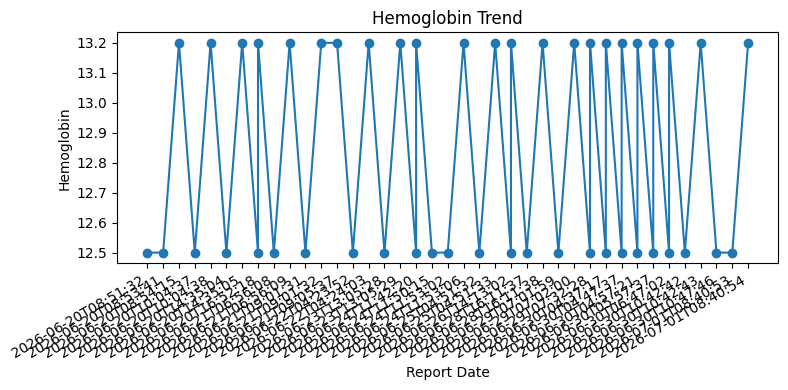

Found 48 data points: [12.5, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 13.2, 12.5, 12.5, 13.2]


In [ ]:
import matplotlib.pyplot as plt
import json

def plot_trend(filename, parameter_name):
    path = f"{project_path}/outputs/{filename}_results.json"
    with open(path, "r") as f:
        history = json.load(f)

    dates, values = [], []
    for entry in history:
        for r in entry['results']:
            if r['parameter'] == parameter_name:
                try:
                    dates.append(entry['uploaded_at'][:19])
                    values.append(float(r['value']))
                except ValueError:
                    pass

    plt.figure(figsize=(8, 4))
    plt.plot(dates, values, marker='o')
    plt.title(f"{parameter_name} Trend")
    plt.xlabel("Report Date")
    plt.ylabel(parameter_name)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f"{project_path}/outputs/{parameter_name}_trend.png")
    plt.show()
    print(f"Found {len(values)} data points: {values}")

plot_trend("patient_history", "Hemoglobin")

**Creating Streamlit app**

In [ ]:
pip install -r requirements1.txt

  Using cached pillow-11.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.5 MB/s eta 0:00:00
Using cached pillow-11.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 63.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 12.2.0
    Uninstalling pillow-12.2.0:
      Successfully uninstalled pillow-12.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdfplumber 0.11.10 requires Pillow>=12.2.0, but you have pillow 11.3.0 which is incompatible.


In [ ]:
!pip install streamlit -q
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
%%writefile app.py
"""
Medical Report Analyzer -- Streamlit App
OCR -> Hybrid (regex + biomedical NER) Extraction -> Plain-language explanation -> Trend tracking

Run with: streamlit run app.py
"""

import streamlit as st
import re
import json
import os
import io
import base64
from datetime import datetime
import pandas as pd
import plotly.graph_objects as go
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors as rl_colors
from reportlab.lib.units import inch
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
st.set_page_config(page_title="MedReport AI", page_icon="🩺", layout="wide", initial_sidebar_state="expanded")

HISTORY_FILE = "patient_history.json"

ACCENT = "#5B7FE0"
ACCENT_PINK = "#E07FA8"
SIDEBAR_BG = "#1B1A23"
PAGE_BG = "#FDF3F8"
CARD_BG = "#FFFFFF"

STATUS_HEX = {"LOW": "#3A5FA8", "HIGH": "#B8568A", "NORMAL": "#4C7A6E", "UNKNOWN": "#7A7685"}
STATUS_BG = {"LOW": "#E7EDFB", "HIGH": "#FBE7F1", "NORMAL": "#E6F2EE", "UNKNOWN": "#EFEDF3"}
STATUS_DOT = {"LOW": "#6C8FE0", "HIGH": "#E0729F", "NORMAL": "#6FA893", "UNKNOWN": "#A39FB0"}
PIE_PALETTE = ["#6C8FE0", "#E0729F", "#F2A6C6", "#8FB3EA", "#C97FB0", "#5B7FE0",
               "#F0C2D8", "#A7C0F0", "#D88BAE", "#7FA0E8", "#EFA8C8"]

KNOWN_PARAMETERS_SORTED = sorted([
    # --- CBC / Hematology ---
    "White Blood Cell", "WBC", "TLC", "Total Leucocyte Count",
    "Red Blood Cell", "RBC", "R B C",
    "Hemoglobin", "Haemoglobin", "Hgb", "HB",
    "Hematocrit", "Haematocrit", "HCT", "PCV",
    "Mean Cell Volume", "Mean Corp Volume", "Mean Volume", "MCV", "M C V",
    "Mean Cell Hemoglobin", "Mean Corp Hb", "Mean Hb", "MCH", "M C H",
    "Mean Cell Hb Conc", "Mean Corp Hb Conc", "MCHC", "M C H C",
    "Red Cell Dist Width", "RDW",
    "Platelet count", "Platelet Count", "Platelet",
    "Mean Platelet Volume", "MPV",
    "Neutrophil", "Lymphocyte", "Monocyte", "Eosinophil", "Basophil",
    # --- Renal Profile ---
    "Blood Urea", "Urea",
    "Serum Creatinine", "Creatinine",
    "Serum Sodium", "Sodium",
    "Serum Potassium", "S. Potassium", "Potassium",
    # --- Liver Profile ---
    "Serum Alkaline Phosphatase", "S. Alkaline Phosphatase", "Alkaline Phosphatase",
    "SGOT", "AST", "SGOT/AST",
    "SGPT", "ALT", "SGPT/ALT", "SGPT IALT",
    "Serum Bilirubin", "Bilirubin",
], key=len, reverse=True)

FRAGMENT_ALIASES = {"##hils": "Neutrophil", "l": "Lymphocyte", "e": "Eosinophil", "mono": "Monocyte"}

EXPLANATIONS = {
    "Hemoglobin": "Think of hemoglobin as the delivery truck for oxygen in your blood — it picks up oxygen from your lungs and drops it off everywhere your body needs it. If it's low, your body isn't getting enough oxygen, which is why you feel tired or weak.",
    "RBC": "Red blood cells are tiny disc-shaped cells that carry hemoglobin around your body. Think of them as the trucks themselves — the more you have, the more oxygen can be delivered.",
    "WBC": "White blood cells are your body's soldiers — they fight off bacteria, viruses, and infections. A high count usually means your body is currently fighting something; a very low count means your defences are down.",
    "TLC": "This is just a count of all the different types of white blood cells (your infection-fighting soldiers) added together. It gives doctors a quick overview of how your immune system is doing.",
    "MCH": "This tells you how much oxygen-carrying protein (hemoglobin) is packed into each individual red blood cell. Think of it as checking whether each delivery truck is fully loaded or running light.",
    "MCHC": "Similar to MCH, but this measures the concentration — how dense the hemoglobin is inside each red blood cell. Like checking how tightly packed the cargo is.",
    "RDW": "This checks whether your red blood cells are all roughly the same size or very uneven. A high value means they're quite varied in size, which can point to nutritional deficiencies.",
    "Platelet count": "Platelets are the tiny cells that form clots when you bleed — like the repair crew that patches up leaks. Too few means you might bleed more than normal; too many can increase clotting risk.",
    "Neutrophil": "Neutrophils are the first responders of your immune system — they rush to the site of bacterial infections and destroy the bacteria. Think of them as your body's emergency response team.",
    "Lymphocyte": "Lymphocytes are the specialists of your immune system — they remember past infections and create antibodies. They're especially active against viral infections.",
    "Eosinophil": "Eosinophils deal mainly with allergies and parasites. If this is high, your body may be reacting to an allergen (like pollen or dust) or fighting a parasitic infection.",
    "Monocyte": "Monocytes are the cleanup crew — they eat up dead cells, bacteria, and debris after an infection is fought off. They're also involved in long-term immune responses.",
    "Hematocrit": "This is simply the percentage of your blood that is made up of red blood cells (the rest is liquid plasma). Low means not enough red cells; high means the blood is too thick.",
    "Mean Cell Volume": "This measures the average size of your red blood cells. Too small often points to iron deficiency; too large often points to vitamin B12 or folate deficiency.",
    "Mean Platelet Volume": "This measures the average size of your platelets. Larger platelets are generally more active and work better at clotting.",
    "Blood Urea": "Urea is a waste product your body makes when it breaks down protein — your kidneys filter it out of your blood. High levels usually mean the kidneys aren't filtering as well as they should.",
    "Creatinine": "Creatinine is another waste product (from muscle activity) that your kidneys filter out. It's one of the most reliable ways to check kidney health — high levels are a red flag.",
    "Sodium": "Sodium controls the balance of water in and around your cells — think of it as regulating how swollen or shrivelled your cells are. It also plays a role in nerve and muscle signals.",
    "Potassium": "Potassium is critical for your heart to beat properly and for your muscles to work. Even small imbalances can affect your heartbeat, which is why doctors watch it closely.",
    "Alkaline Phosphatase": "This enzyme is found mainly in your liver and bones. High levels can indicate liver disease, bile duct problems, or bone disorders — your doctor will look at other tests together with this one.",
    "SGOT/AST": "This is a liver enzyme that leaks into the blood when liver cells are damaged. Think of it as an alarm signal — the higher it is, the more stress the liver is under.",
    "SGPT/ALT": "This is the most specific liver enzyme test — it's found almost exclusively in the liver, so a high value is a strong indicator of liver damage or inflammation.",
    "Bilirubin": "Bilirubin is a yellow substance made when old red blood cells are broken down. The liver processes and removes it. High levels cause the skin and eyes to turn yellow (jaundice) — a sign the liver may not be working properly.",
    "Mean Cell Hemoglobin": "This tells you the average weight of hemoglobin (the oxygen-carrying protein) in each red blood cell. Low values often suggest iron deficiency.",
}

NAME_CANONICALIZE = {
    "Haemoglobin": "Hemoglobin",
    "TLC": "WBC", "Total Leucocyte Count": "WBC",
    "Red Blood Cell": "RBC", "R B C": "RBC",
    "Mean Corp Volume": "Mean Cell Volume", "Mean Volume": "Mean Cell Volume", "M C V": "Mean Cell Volume",
    "Mean Corp Hb": "Mean Cell Hemoglobin", "Mean Hb": "Mean Cell Hemoglobin",
    "M C H": "Mean Cell Hemoglobin",
    "Mean Corp Hb Conc": "Mean Cell Hb Conc", "M C H C": "Mean Cell Hb Conc",
    "Haematocrit": "Hematocrit", "PCV": "Hematocrit",
    "Platelet Count": "Platelet count",
    "Urea": "Blood Urea",
    "Serum Creatinine": "Creatinine",
    "Serum Sodium": "Sodium",
    "Serum Potassium": "Potassium", "S. Potassium": "Potassium",
    "Serum Alkaline Phosphatase": "Alkaline Phosphatase",
    "S. Alkaline Phosphatase": "Alkaline Phosphatase",
    "SGOT": "SGOT/AST", "AST": "SGOT/AST",
    "SGPT": "SGPT/ALT", "ALT": "SGPT/ALT", "SGPT IALT": "SGPT/ALT",
    "Serum Bilirubin": "Bilirubin",
}


# ---------------------------------------------------------------------------
# DESIGN SYSTEM
# ---------------------------------------------------------------------------
def inject_css():
    st.markdown(f"""
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Source+Serif+4:wght@500;600;700&family=Inter:wght@400;500;600;700&display=swap');

    html, body, [class*="css"] {{ font-family: 'Inter', sans-serif; font-size: 15px; }}
    .stApp {{ background-color: {PAGE_BG}; }}

    h1, h2, h3 {{ font-family: 'Source Serif 4', serif !important; color: #2B2640 !important; font-weight: 600 !important; }}
    h1 {{ letter-spacing: -0.5px; font-size: 30px !important; }}
    h4 {{ font-family: 'Inter', sans-serif !important; font-weight: 600 !important; color: #2B2640 !important; font-size: 17px !important; }}

    /* ---------- Sidebar ---------- */
    section[data-testid="stSidebar"] {{
        background-color: {SIDEBAR_BG};
        border-right: none;
    }}
    section[data-testid="stSidebar"] * {{ color: #D6D3E0; }}
    section[data-testid="stSidebar"] h1 {{ color: #FFFFFF !important; font-size: 18px !important; }}
    .sidebar-logo-text {{ font-size: 21px !important; font-weight: 700 !important; color: #FFFFFF !important; letter-spacing: -0.3px; }}

    /* Style the radio nav as zoom-on-hover buttons */
    section[data-testid="stSidebar"] div[role="radiogroup"] {{
        display: flex; flex-direction: column; width: 100%;
    }}
    section[data-testid="stSidebar"] div[role="radiogroup"] > label {{
        display: flex; align-items: center; width: 100%; box-sizing: border-box;
        background: #262335; border-radius: 10px; padding: 12px 14px; margin-bottom: 10px;
        border: 1px solid transparent;
        transition: transform 0.18s ease, background 0.18s ease, border-color 0.18s ease;
        cursor: pointer;
    }}
    section[data-testid="stSidebar"] div[role="radiogroup"] > label:hover {{
        transform: scale(1.045);
        background: #2E2A42;
        border-color: {ACCENT_PINK};
    }}
    section[data-testid="stSidebar"] div[role="radiogroup"] > label > div:first-child {{
        display: none;
    }}
    section[data-testid="stSidebar"] div[role="radiogroup"] > label p {{
        font-size: 14px !important; font-weight: 500; color: #EDEBF5 !important;
    }}

    /* ---------- Cards & containers ---------- */
    .panel-box {{
        background: {CARD_BG}; border-radius: 16px; padding: 1.4rem 1.5rem;
        border: 1px solid #F0DCE8; box-shadow: 0 1px 3px rgba(120,80,110,0.06);
    }}

    .metric-card {{
        background: {CARD_BG}; border-radius: 14px; padding: 16px 18px;
        border: 1px solid #F0DCE8; border-bottom: 3px solid var(--accent, #888);
        transition: transform 0.15s ease, box-shadow 0.15s ease;
    }}
    .metric-card:hover {{ transform: translateY(-2px); box-shadow: 0 4px 14px rgba(120,80,110,0.10); }}
    .metric-label {{ font-size: 12.5px; color: #8A8398; }}
    .metric-value {{ font-size: 28px; font-weight: 600; margin-top: 2px; color: #2B2640; }}

    .upload-heading {{
        font-size: 13px; font-weight: 600; letter-spacing: 0.04em; color: #B0568A;
        text-transform: uppercase; margin-bottom: 0.4rem;
    }}

    .detail-card {{
        background: linear-gradient(135deg, {ACCENT} 0%, {ACCENT_PINK} 100%);
        border-radius: 16px; padding: 1.3rem 1.4rem; color: white;
        height: 460px; box-sizing: border-box;
        display: flex; flex-direction: column; justify-content: center; gap: 8px;
    }}
    .detail-pill {{
        font-size: 11px; font-weight: 600; padding: 3px 11px; border-radius: 999px;
        background: rgba(255,255,255,0.25); letter-spacing: 0.03em;
    }}

    .result-row {{
        display: flex; align-items: center; gap: 12px; padding: 13px 18px; border-radius: 12px;
        background: {CARD_BG}; border: 1px solid #F0DCE8; margin-bottom: 9px;
        transition: transform 0.12s ease, box-shadow 0.12s ease;
    }}
    .result-row:hover {{ transform: translateX(3px); box-shadow: 0 2px 10px rgba(120,80,110,0.08); }}
    .result-status-pill {{ font-size: 11.5px; font-weight: 600; padding: 4px 12px; border-radius: 999px; }}

    .stButton button {{
        border-radius: 10px; font-size: 13.5px; font-weight: 500;
        transition: transform 0.15s ease;
        border: 1px solid #E8D5E0;
    }}
    .stButton button:hover {{ transform: translateY(-1px); border-color: {ACCENT_PINK}; }}
    .stButton button[kind="primary"] {{
        background: linear-gradient(135deg, {ACCENT} 0%, {ACCENT_PINK} 100%); border: none; color: white;
    }}

    .step-row {{ display: flex; align-items: center; gap: 8px; font-size: 13px; color: #8A8398; padding: 4px 0; }}
    .step-row.done {{ color: #4C7A6E; }}
    .step-row.active {{ color: {ACCENT_PINK}; font-weight: 500; }}

    [data-testid="stFileUploaderDropzone"] {{
        background: #FFFCFD !important; border: 1.5px dashed #E8B8D0 !important; border-radius: 14px !important;
        transition: border-color 0.2s ease, background 0.2s ease;
    }}
    [data-testid="stFileUploaderDropzone"]:hover {{
        border-color: {ACCENT_PINK} !important; background: #FFF6FA !important;
    }}

    .panel-box {{ transition: box-shadow 0.18s ease; }}
    .panel-box:hover {{ box-shadow: 0 4px 16px rgba(120,80,110,0.10); }}

    /* Native Streamlit bordered containers -- used instead of markdown div-wrapping
       (which doesn't actually enclose chart elements and was causing stray empty boxes) */
    [data-testid="stVerticalBlockBorderWrapper"] {{
        border-radius: 16px !important;
        border-color: #F0DCE8 !important;
        background: {CARD_BG} !important;
        transition: box-shadow 0.18s ease;
    }}
    [data-testid="stVerticalBlockBorderWrapper"]:hover {{
        box-shadow: 0 4px 16px rgba(120,80,110,0.10);
    }}

    .stButton button:active {{ transform: translateY(0) scale(0.97); }}
    .stButton button[kind="secondary"] {{
        background: #FFFFFF; color: #2B2640; font-size: 12px; padding: 6px 10px;
    }}
    .stButton button[kind="primary"] {{
        font-size: 12px; padding: 6px 10px;
    }}

    [data-testid="stSelectbox"] > div > div {{
        border-radius: 10px !important; border-color: #E8D5E0 !important;
        transition: border-color 0.18s ease;
    }}
    [data-testid="stSelectbox"] > div > div:hover {{ border-color: {ACCENT_PINK} !important; }}

    [data-testid="stExpander"] {{
        border-radius: 12px !important; border-color: #F0DCE8 !important;
        background: {CARD_BG} !important;
    }}
    [data-testid="stExpander"] summary {{
        color: #2B2640 !important;
    }}
    [data-testid="stExpander"] summary span,
    [data-testid="stExpander"] summary p {{
        color: #2B2640 !important;
    }}

    /* Tighten default Streamlit block spacing so nothing feels like leftover dead space */
    .block-container {{ padding-top: 2.2rem; }}
    div[data-testid="stVerticalBlock"] > div {{ gap: 0.5rem; }}

    div[role="radiogroup"] label p {{
    color: #2B2640 !important;
    font-size: 13px !important;
}}
    </style>
    """, unsafe_allow_html=True)


# ---------------------------------------------------------------------------
# CACHED MODEL LOADERS
# ---------------------------------------------------------------------------
@st.cache_resource
def load_ocr_reader():
    import easyocr
    return easyocr.Reader(['en'], gpu=False)


@st.cache_resource
def load_ner_pipeline():
    from transformers import pipeline
    return pipeline("ner", model="d4data/biomedical-ner-all", aggregation_strategy="simple")


# ---------------------------------------------------------------------------
# PIPELINE FUNCTIONS
# ---------------------------------------------------------------------------
def pdf_to_images(pdf_path):
    from pdf2image import convert_from_path
    poppler_path = os.environ.get("POPPLER_PATH", None)
    if poppler_path:
        return convert_from_path(pdf_path, dpi=200, poppler_path=poppler_path)
    return convert_from_path(pdf_path, dpi=200)


def run_ocr(reader, image_path):
    """
    Returns (full_text, average_confidence, detections).
    detections is a list of (text, confidence, center_y, left_x) for every confident
    OCR box -- kept so we can reconstruct visual ROWS later, since OCR's raw reading
    order doesn't always match the report's actual label/value column layout.
    """
    results = reader.readtext(image_path)
    full_text = ""
    confidences = []
    detections = []
    for (bbox, text, confidence) in results:
        if confidence >= 0.4:
            full_text += text + " "
            confidences.append(confidence)
            xs = [pt[0] for pt in bbox]
            ys = [pt[1] for pt in bbox]
            detections.append({
                "text": text, "confidence": confidence,
                "center_y": sum(ys) / len(ys), "left_x": min(xs), "height": max(ys) - min(ys),
            })
    avg_conf = sum(confidences) / len(confidences) if confidences else 0
    return full_text.strip(), avg_conf, detections


def group_into_rows(detections):
    """
    Clusters OCR detections into visual rows based on vertical (Y) position, then
    sorts each row left-to-right by X position.

    Key design choices:
    - Tolerance = height * 0.4 (tighter than the usual 0.5-0.7) because this report
      has closely-spaced rows that were merging together at higher tolerance values,
      causing values from one row to bleed into the adjacent row's label.
    - We compare each new detection against the FIRST detection in the current row
      (not the last), because as rows accumulate left-to-right, the last detection's
      Y may have drifted slightly, causing cascading row-merges.
    """
    if not detections:
        return []
    sorted_dets = sorted(detections, key=lambda d: d["center_y"])
    rows = []
    current_row = [sorted_dets[0]]
    row_anchor_y = sorted_dets[0]["center_y"]
    row_tolerance = sorted_dets[0]["height"] * 0.4

    for det in sorted_dets[1:]:
        if abs(det["center_y"] - row_anchor_y) <= row_tolerance:
            current_row.append(det)
        else:
            rows.append(sorted(current_row, key=lambda d: d["left_x"]))
            current_row = [det]
            row_anchor_y = det["center_y"]
            row_tolerance = det["height"] * 0.4
    rows.append(sorted(current_row, key=lambda d: d["left_x"]))
    return rows


def clean_parameter_name(raw_guess):
    """
    Matches OCR text against known parameter names, with two normalizations applied
    before matching to handle common OCR misread patterns:

    1. Collapse spaces between single letters: 'R B C' → 'RBC', 'M C H C' → 'MCHC'
       This handles the common OCR pattern where abbreviations get spaces inserted
       between each letter.

    2. Replace capital I with slash: 'SGPT IALT' → 'SGPT/ALT', 'UIL' → 'U/L'
       OCR frequently misreads '/' as 'I' in certain fonts.
    """
    # Normalize: collapse spaced single-letter abbreviations ('R B C' → 'RBC')
    normalized = re.sub(r'\b([A-Za-z])\s(?=[A-Za-z]\b)', r'\1', raw_guess)
    # Normalize: replace ' I' (space + capital I) with '/' for slash misreads
    normalized = re.sub(r'\s[I]\s', '/', normalized)

    for known_name in KNOWN_PARAMETERS_SORTED:
        if known_name.lower() in normalized.lower():
            return NAME_CANONICALIZE.get(known_name, known_name)
        # Also try original raw_guess in case normalization went wrong
        if known_name.lower() in raw_guess.lower():
            return NAME_CANONICALIZE.get(known_name, known_name)

    alias = FRAGMENT_ALIASES.get(raw_guess.strip().lower())
    return NAME_CANONICALIZE.get(alias, alias)


UNIT_PATTERN = r'(g\s?[/l]\s?d[lL]|mg\s?/\s?dL|mill\s?/\s?cumm|millions\s?[/I]\s?cu\s?mm|[/I]\s?cu\s?mm|K\s?/\s?mcL|M\s?/\s?mcL|fL|fl|pg|cumm|/\s?uL|GM\s?%|mmol\s?/\s?L|U\s?[/I]\s?L|mg\s?%|[xX]\s?10[\d³\']?|%)'
NUMBER_PATTERN = r'\d+\.?\d*'


def extract_by_row(rows):
    """
    Position-aware row-based extraction.

    Key insight: in column-style lab reports (Label | Value | Unit | Range),
    the label is always in the LEFTMOST column. So instead of searching the
    whole row text for a known parameter name (which picks up stray text),
    we:
    1. Look for the parameter name in the LEFT portion of the row only
       (detections whose left_x is less than 40% of the row's width)
    2. Grab numbers ONLY from detections to the RIGHT of the label detection
       (detections whose left_x is greater than the label's right edge)

    This prevents range numbers from a higher row contaminating a lower row's
    label, and prevents value/unit columns from being misread as parameter names.
    """
    if not rows:
        return []

    # Estimate page width from the rightmost detection across all rows
    all_xs = [d["left_x"] for row in rows for d in row]
    page_right = max(all_xs) if all_xs else 1000
    label_zone_cutoff = page_right * 0.40  # left 40% = label column

    records = []
    for row in rows:
        if not row:
            continue

        # Step 1: find the label — search only left-zone detections
        label_dets = [d for d in row if d["left_x"] <= label_zone_cutoff]
        label_text = " ".join(d["text"] for d in label_dets)
        matched_name = clean_parameter_name(label_text)

        if not matched_name:
            # Fallback: try the full row text in case label spans into mid-column
            full_row_text = " ".join(d["text"] for d in row)
            matched_name = clean_parameter_name(full_row_text)
            if not matched_name:
                continue

        # Step 2: find where the label ends (rightmost X of label detections)
        label_right = max(d["left_x"] for d in (label_dets if label_dets else row))

        # Step 3: grab numbers and unit ONLY from detections to the right of the label
        value_dets = [d for d in row if d["left_x"] > label_right]
        if not value_dets:
            continue
        value_text = " ".join(d["text"] for d in value_dets)

        # Handle comma-separated thousands (8,000 → 8000) and split decimals (0. 8 → 0.8)
        value_text_clean = clean_ocr_numbers(value_text)

        numbers = re.findall(NUMBER_PATTERN, value_text_clean)
        if not numbers:
            continue

        unit_match = re.search(UNIT_PATTERN, value_text, re.IGNORECASE)
        unit = unit_match.group(1).strip() if unit_match else "NOT_FOUND"

        records.append({"parameter": matched_name, "numbers_found": numbers[:3], "unit": unit})
    return records


def extract_with_hybrid(text, ner_results):
    """Text-order fallback extraction (used for reports where rows aren't cleanly row-separated)."""
    records = []
    procedures = [r for r in ner_results if r['entity_group'] == 'Diagnostic_procedure']
    number_pattern = r'\d+\.?\d*'

    for i, proc in enumerate(procedures):
        name = proc['word']
        start = proc['end']
        end = procedures[i + 1]['start'] if i + 1 < len(procedures) else len(text)
        chunk = text[start:end]

        numbers = re.findall(number_pattern, chunk)
        unit_match = re.search(UNIT_PATTERN, chunk, re.IGNORECASE)
        unit = unit_match.group(1) if unit_match else "NOT_FOUND"

        matched_name = clean_parameter_name(name)
        if matched_name and numbers:
            records.append({"parameter": matched_name, "numbers_found": numbers[:3], "unit": unit})
    return records


def merge_records(row_records, text_order_records):
    """
    Combines both extraction strategies: row-based results are trusted first (since
    they're geometrically grounded and immune to text-order bugs); text-order results
    fill in any parameter the row-based pass missed entirely (e.g. a label/value pair
    OCR happened to read on a single line already).
    """
    merged = {}
    for r in row_records:
        merged[r["parameter"]] = r
    for r in text_order_records:
        if r["parameter"] not in merged:
            merged[r["parameter"]] = r
    return list(merged.values())


def flag_value(value, low, high):
    try:
        v, lo, hi = float(value), float(low), float(high)
    except (ValueError, TypeError):
        return "UNKNOWN"
    if v < lo:
        return "LOW"
    if v > hi:
        return "HIGH"
    return "NORMAL"


def clean_ocr_numbers(text):
    """
    Fixes three distinct OCR misread patterns seen in real Indian lab reports:

    1. SPLIT DECIMAL TOKEN ('0. 8' → '0.8'): OCR reads dot but adds space after it.
    2. COMMA AS DECIMAL ('3,6' → '3.6') vs THOUSANDS ('8,000' → '8000'):
       If digits after comma are 1-2 chars → decimal. If 3+ chars → thousands separator.
    3. SPACE AS DECIMAL ('90 0' → '90.0', '0 8' → '0.8'):
       OCR drops the decimal point entirely, leaving a space.
       Rule: single digit space single digit → decimal (catches '0 8', '3 6' etc.)
       Multi-digit space single digit → decimal (catches '90 0', '30 9' etc.)
       Multi-digit space multi-digit → leave alone (keeps range pairs like '40 80').
    """
    # Fix 1: split dot token ('0. 8' → '0.8')
    text = re.sub(r'(\d+)\.\s+(\d+)', r'\1.\2', text)

    # Fix 2: comma as decimal vs thousands
    def fix_comma(m):
        before, after = m.group(1), m.group(2)
        return f"{before}.{after}" if len(after) <= 2 else f"{before}{after}"
    text = re.sub(r'(\d+),(\d+)', fix_comma, text)

    # Fix 3: space as decimal — single digit on either side
    # '\d \d(?!\d)' catches '0 8', '3 6', '90 0', '30 9' without touching '40 80'
    text = re.sub(r'(\d)\s(\d)(?!\d)', r'\1.\2', text)

    return text


def explain_record(r):
    nums = r['numbers_found']
    val = nums[0]
    low = nums[1] if len(nums) > 1 else None
    high = nums[2] if len(nums) > 2 else None

    status = flag_value(val, low, high)
    description = EXPLANATIONS.get(r['parameter'], "No description available for this test.")

    if low and high:
        range_str = f"{low}-{high}"
    elif low:
        range_str = f">{low}"
    else:
        range_str = "Not found in report"
        status = "UNKNOWN"

    return {
        "parameter": r['parameter'],
        "value": val,
        "unit": r['unit'],
        "range": range_str,
        "status": status,
        "description": description,
    }


def extract_with_gemini(image_path, api_key):
    """
    Sends the lab report image to Gemini Vision API and asks it to extract
    all lab values as structured JSON. Used as a fallback when the local
    OCR+NER pipeline extracts fewer values than expected or has low confidence.

    Returns a list of explained records in the same format as explain_record(),
    or None if the API call fails.
    """
    try:
        import google.generativeai as genai
        genai.configure(api_key=api_key)

        with open(image_path, "rb") as f:
            image_bytes = f.read()

        image_part = {
            "mime_type": "image/png",
            "data": base64.b64encode(image_bytes).decode("utf-8")
        }

        prompt = """You are a medical lab report analyzer. Look at this lab report image carefully.

Extract ALL test parameters you can see — including CBC, Renal Profile, Liver Profile, or any other panels present.

Return ONLY a valid JSON array, no other text, no markdown, no explanation.
Each item must have exactly these fields:
- "parameter": the test name (e.g. "Hemoglobin", "WBC", "Creatinine")
- "value": the numeric result as a string (e.g. "10.8", "8000")
- "unit": the unit (e.g. "g/dL", "/cu mm", "mg%") or "NOT_FOUND" if not visible
- "range": the reference range as "low-high" (e.g. "12.0-16.0") or "Not found in report" if not visible
- "status": "LOW", "HIGH", "NORMAL", or "UNKNOWN" based on comparing value to range
- "description": one plain-English sentence explaining what this test measures

Example output format:
[
  {
    "parameter": "Hemoglobin",
    "value": "10.8",
    "unit": "g/dL",
    "range": "12.0-16.0",
    "status": "LOW",
    "description": "Hemoglobin carries oxygen in your blood."
  }
]

Extract every single test you can see. Do not skip any."""

        model = genai.GenerativeModel("gemini-2.5-flash-lite")
        response = model.generate_content([
            {"role": "user", "parts": [
                {"text": prompt},
                {"inline_data": image_part}
            ]}
        ])

        raw = response.text.strip()
        # Strip markdown code fences if present
        raw = re.sub(r'^```(?:json)?\s*', '', raw, flags=re.MULTILINE)
        raw = re.sub(r'\s*```$', '', raw, flags=re.MULTILINE)
        raw = raw.strip()

        records = json.loads(raw)

        # Validate and normalize each record
        cleaned = []
        for r in records:
            if not isinstance(r, dict):
                continue
            cleaned.append({
                "parameter": str(r.get("parameter", "Unknown")),
                "value":     str(r.get("value", "N/A")),
                "unit":      str(r.get("unit", "NOT_FOUND")),
                "range":     str(r.get("range", "Not found in report")),
                "status":    str(r.get("status", "UNKNOWN")).upper(),
                "description": str(r.get("description", "No description available.")),
            })
        return cleaned

    except Exception as e:
        st.session_state["gemini_last_error"] = str(e)
        return None  # Caller checks st.session_state['gemini_last_error'] if needed


def normalize_parameter_name(name):
    """
    Normalizes a parameter name to a consistent canonical form before saving
    to history, so variants like 'HAEMOGLOBIN', 'Haemoglobin', 'haemoglobin'
    all get stored under the same key and appear as one trend line.
    Checks title-case, original, and uppercase forms against NAME_CANONICALIZE.
    """
    s = name.strip()
    for candidate in [s, s.title(), s.upper()]:
        if candidate in NAME_CANONICALIZE:
            return NAME_CANONICALIZE[candidate]
    return s.title()  # default: title-case for consistent display


def save_to_history(results):
    # Normalize parameter names before saving so variant spellings
    # from different reports merge into one trend line
    normalized_results = []
    for r in results:
        normalized = dict(r)
        normalized["parameter"] = normalize_parameter_name(r["parameter"])
        normalized_results.append(normalized)

    record = {"uploaded_at": datetime.now().isoformat(), "results": normalized_results}
    history = []
    if os.path.exists(HISTORY_FILE):
        with open(HISTORY_FILE, "r") as f:
            history = json.load(f)
    history.append(record)
    with open(HISTORY_FILE, "w") as f:
        json.dump(history, f, indent=2)
    return len(history)


def load_history():
    if os.path.exists(HISTORY_FILE):
        with open(HISTORY_FILE, "r") as f:
            history = json.load(f)
        # Normalize parameter names on load to fix any pre-existing variant spellings
        for entry in history:
            for r in entry.get("results", []):
                r["parameter"] = normalize_parameter_name(r["parameter"])
        return history
    return []


# ---------------------------------------------------------------------------
# SIDEBAR
# ---------------------------------------------------------------------------
def render_sidebar():
    with st.sidebar:
        st.markdown(f"""
        <div style="display:flex; align-items:center; gap:11px; margin-bottom:2rem;">
            <div style="width:40px; height:40px; border-radius:11px;
                        background:linear-gradient(135deg,{ACCENT} 0%,{ACCENT_PINK} 100%);
                        display:flex; align-items:center; justify-content:center; font-size:20px; flex-shrink:0;">🩺</div>
            <span class="sidebar-logo-text">MedReport AI</span>
        </div>
        """, unsafe_allow_html=True)

        page = st.radio(
            "nav", ["📄   Analyze report", "📈   Trend history"],
            label_visibility="collapsed", key="nav_page"
        )
    return page


# ---------------------------------------------------------------------------
# ANALYZE PAGE
# ---------------------------------------------------------------------------
def render_analyze_page():
    st.markdown("# MedReport AI")
    st.markdown(
        '<p style="color:#8A8398; margin-top:-0.6rem; font-size:15px;">Upload a lab report and get a clear, '
        'plain-language breakdown of your results — in under a minute.</p>', unsafe_allow_html=True
    )

    # --- Feature row: gives the empty state some life instead of jumping straight to a bare upload box ---
    if "processed_file_signature" not in st.session_state:
        st.markdown("<div style='margin-top:0.5rem;'></div>", unsafe_allow_html=True)
        f1, f2, f3 = st.columns(3)
        features = [
            (f1, "🔍", "OCR + AI extraction", "Reads PDFs and photos of lab reports using OCR and biomedical NLP."),
            (f2, "🚩", "Flags what matters", "Automatically highlights values outside the normal range."),
            (f3, "📈", "Tracks over time", "Save reports to see how your values trend across visits."),
        ]
        for col, icon, title, desc in features:
            with col:
                st.markdown(f"""
                <div class="panel-box" style="text-align:left; min-height:118px;">
                    <div style="font-size:22px; margin-bottom:6px;">{icon}</div>
                    <div style="font-weight:600; font-size:14px; color:#2B2640; margin-bottom:3px;">{title}</div>
                    <div style="font-size:12.5px; color:#8A8398; line-height:1.45;">{desc}</div>
                </div>
                """, unsafe_allow_html=True)

    st.markdown("<div style='margin-top:1.25rem;'></div>", unsafe_allow_html=True)
    st.markdown('<div class="upload-heading">Step 1 — Upload your report</div>', unsafe_allow_html=True)
    uploaded_file = st.file_uploader("Upload a lab report (PDF)", type=["pdf"], label_visibility="collapsed")

    if uploaded_file is None:
        return

    # --- Cache key: only reprocess if this is a NEW file, not on every UI interaction ---
    file_signature = f"{uploaded_file.name}_{uploaded_file.size}"

    if st.session_state.get("processed_file_signature") != file_signature:
        with open("temp_upload.pdf", "wb") as f:
            f.write(uploaded_file.getbuffer())

        # --- Step-by-step processing indicator ---
        step_box = st.empty()
        steps = ["Reading PDF", "Running OCR", "Loading biomedical NER", "Extracting values", "Generating explanations"]

        def render_steps(active_idx):
            html = ""
            for i, s in enumerate(steps):
                cls = "done" if i < active_idx else ("active" if i == active_idx else "")
                icon = "✅" if i < active_idx else ("⏳" if i == active_idx else "◯")
                html += f'<div class="step-row {cls}">{icon} {s}</div>'
            step_box.markdown(html, unsafe_allow_html=True)

        render_steps(0)
        images = pdf_to_images("temp_upload.pdf")
        images[0].save("temp_page.png")

        render_steps(1)
        reader = load_ocr_reader()
        raw_text, avg_confidence, detections = run_ocr(reader, "temp_page.png")

        render_steps(2)
        ner_pipe = load_ner_pipeline()

        render_steps(3)
        ner_results = ner_pipe(raw_text)
        text_order_records = extract_with_hybrid(raw_text, ner_results)
        rows = group_into_rows(detections)
        row_records = extract_by_row(rows)
        hybrid_records = merge_records(row_records, text_order_records)

        render_steps(4)
        explained = [explain_record(r) for r in hybrid_records]
        step_box.empty()

        # Save local OCR results before Gemini potentially replaces them
        # so the user can toggle between both views
        local_explained = explained[:]

        # --- Gemini Vision fallback ---
        # Local pipeline runs first (above). Gemini is only called when OCR confidence
        # falls below GEMINI_CONFIDENCE_THRESHOLD -- i.e. when local extraction is
        # likely unreliable.
        #
        # Key is read from the GEMINI_API_KEY environment variable, NOT Colab Secrets
        # directly -- because Streamlit runs as a separate subprocess (via
        # subprocess.Popen) and does not inherit the notebook's userdata/Secrets
        # context. Environment variables DO pass through to subprocesses, so the
        # correct setup is: in a Colab cell, before starting Streamlit, run:
        #     import os
        #     from google.colab import userdata
        #     os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')
        GEMINI_CONFIDENCE_THRESHOLD = 0.95
        gemini_key = os.environ.get('GEMINI_API_KEY', "")

        extraction_method = "local"

        if gemini_key and avg_confidence < GEMINI_CONFIDENCE_THRESHOLD:
            with st.spinner(f"⚠️ OCR confidence ({avg_confidence*100:.0f}%) below {GEMINI_CONFIDENCE_THRESHOLD*100:.0f}% — refining with Gemini Vision AI..."):
                gemini_results = extract_with_gemini("temp_page.png", gemini_key)

            if gemini_results:
                explained = gemini_results
                extraction_method = "gemini"
            else:
                error_detail = st.session_state.get("gemini_last_error", "Unknown error")
                st.warning(f"Gemini Vision API call failed — showing local extraction results.\n\nError: {error_detail}")

        # Save results into session_state so future reruns (pie clicks, dropdowns) skip reprocessing
        st.session_state.processed_file_signature = file_signature
        st.session_state.cached_explained = explained
        st.session_state.cached_local_explained = local_explained
        st.session_state.cached_raw_text = raw_text
        st.session_state.cached_avg_confidence = avg_confidence
        st.session_state.cached_filename = uploaded_file.name
        st.session_state.cached_extraction_method = extraction_method
        st.session_state.selected_param_idx = 0  # reset selection for the new report

    # --- Load from cache (instant on reruns triggered by chart/dropdown clicks) ---
    explained = st.session_state.cached_explained
    local_explained = st.session_state.get("cached_local_explained", explained)
    raw_text = st.session_state.cached_raw_text
    avg_confidence = st.session_state.cached_avg_confidence
    filename = st.session_state.cached_filename
    extraction_method = st.session_state.get("cached_extraction_method", "local")

    if not explained:
        st.error("No recognizable lab values were found in this report. Try a different file.")
        return

    st.markdown("<div style='margin-top:0.5rem;'></div>", unsafe_allow_html=True)
    st.markdown('<div class="upload-heading">Step 2 — Results</div>', unsafe_allow_html=True)
    st.markdown(f"#### {filename}")
    method_badge = (
        '&nbsp;&nbsp;<span style="background:#E6F2EE; color:#3B6D11; font-size:11px; '
        'font-weight:600; padding:2px 9px; border-radius:999px;">✨ Gemini Vision</span>'
        if extraction_method == "gemini" else
        '&nbsp;&nbsp;<span style="background:#E7EDFB; color:#3A5FA8; font-size:11px; '
        'font-weight:600; padding:2px 9px; border-radius:999px;">⚙️ Local AI</span>'
    )
    st.markdown(
        f'<div style="font-size:13px; color:#8A8398; margin-top:-0.4rem;">'
        f'Analyzed just now &nbsp;·&nbsp; OCR confidence {avg_confidence*100:.0f}%'
        f'{method_badge}</div>',
        unsafe_allow_html=True
    )

    # --- View toggle (only shown when Gemini was used and local results differ) ---
    both_available = extraction_method == "gemini" and len(local_explained) > 0
    if both_available:
        st.markdown("<div style='margin-top:0.75rem;'></div>", unsafe_allow_html=True)
        view_options = ["✨ Gemini Vision (default)", "⚙️ Local OCR pipeline"]
        selected_view = st.radio(
            "View results from:",
            view_options,
            horizontal=True,
            label_visibility="collapsed",
            key="results_view_toggle"
        )
        if selected_view == view_options[1]:
            explained = local_explained
        st.markdown("<div style='margin-top:0.5rem;'></div>", unsafe_allow_html=True)

    # --- Metric row ---
    total = len(explained)
    n_normal = sum(1 for e in explained if e['status'] == 'NORMAL')
    n_high = sum(1 for e in explained if e['status'] == 'HIGH')
    n_low = sum(1 for e in explained if e['status'] == 'LOW')
    m1, m2, m3, m4 = st.columns(4)
    metrics = [(m1, "Total values", total, "#8FA8E0"), (m2, "Normal", n_normal, "#6FA893"),
               (m3, "High", n_high, "#E0729F"), (m4, "Low", n_low, "#6C8FE0")]
    for col, label, value, color in metrics:
        with col:
            st.markdown(f"""
            <div class="metric-card" style="--accent:{color};">
                <div class="metric-label">{label}</div>
                <div class="metric-value">{value}</div>
            </div>
            """, unsafe_allow_html=True)

    st.markdown("<div style='margin-top:1.5rem;'></div>", unsafe_allow_html=True)

    # --- Full pie chart (all slices visible) + clickable legend + detail panel ---
    col_chart, col_detail = st.columns([1.15, 1])

    param_names = [e['parameter'] for e in explained]
    values_for_pie = [1 for _ in explained]  # equal-weight slices so every parameter gets its own visible wedge
    slice_colors = [PIE_PALETTE[i % len(PIE_PALETTE)] for i in range(len(param_names))]

    if "selected_param_idx" not in st.session_state:
        st.session_state.selected_param_idx = 0

    with col_chart:
        with st.container(border=True):
            fig = go.Figure(data=[go.Pie(
                labels=param_names, values=values_for_pie, hole=0,
                marker=dict(colors=slice_colors, line=dict(color="#FFFFFF", width=2)),
                textinfo="label", textfont=dict(family="Inter", size=11, color="#2B2640"),
                pull=[0.07 if i == st.session_state.selected_param_idx else 0 for i in range(len(param_names))],
                sort=False,
            )])
            fig.update_layout(
                showlegend=False, margin=dict(t=10, b=10, l=10, r=10), height=300,
                paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
            )
            st.plotly_chart(fig, use_container_width=True, key="status_pie")

            # Clickable legend -- color-dot buttons matched to each slice.
            # (Plotly's native click-to-select on pie charts is unreliable in Streamlit,
            # so this is the guaranteed-to-work way to let you pick a slice by clicking.)
            st.markdown('<div style="font-size:11.5px; color:#8A8398; margin:8px 0 4px;">Click a value:</div>', unsafe_allow_html=True)
            n_cols = 4
            legend_cols = st.columns(n_cols)
            for i, (name, color) in enumerate(zip(param_names, slice_colors)):
                with legend_cols[i % n_cols]:
                    is_selected = (i == st.session_state.selected_param_idx)
                    label = f"● {name}"
                    if st.button(label, key=f"legend_btn_{i}", use_container_width=True,
                                 type="primary" if is_selected else "secondary"):
                        st.session_state.selected_param_idx = i
                        st.rerun()

    with col_detail:
        idx = min(st.session_state.selected_param_idx, len(explained) - 1)
        sel = explained[idx]
        st.markdown(f"""
        <div class="detail-card">
            <div style="display:flex; align-items:center; gap:8px;">
                <span style="font-size:18px; font-weight:600;">{sel['parameter']}</span>
                <span class="detail-pill">{sel['status']}</span>
            </div>
            <div style="font-size:13.5px; opacity:0.9;">{sel['value']} {sel['unit']} &nbsp;·&nbsp; normal range {sel['range']}</div>
            <div style="font-size:13.5px; margin-top:8px; line-height:1.6;">{sel['description']}</div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("<div style='margin-top:1.5rem;'></div>", unsafe_allow_html=True)

    # --- Results table (styled like the original table) ---
    st.markdown("#### All results")
    df = pd.DataFrame(explained)
    df_display = df.rename(columns={
        "parameter": "Parameter", "value": "Result", "unit": "Unit",
        "range": "Reference Range", "status": "Flag"
    })[["Parameter", "Result", "Unit", "Reference Range", "Flag"]]

    def highlight_status(row):
        bg = STATUS_BG.get(row['Flag'], "#EFEDF3")
        return [f"background-color: {bg}; color: #2B2640; font-weight: 500;"] * len(row)

    styled_table = df_display.style.apply(highlight_status, axis=1).set_table_styles([
        {"selector": "th", "props": [("background-color", "#1B1A23"), ("color", "#FFFFFF"),
                                      ("font-weight", "600"), ("padding", "10px 14px")]},
        {"selector": "td", "props": [("padding", "9px 14px")]},
    ])
    st.dataframe(styled_table, use_container_width=True, hide_index=True)

    # --- Actions ---
    def build_pie_chart_image(param_names, slice_colors_local):
        """Renders the status pie chart as a PNG in-memory using matplotlib (for embedding in the PDF)."""
        fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
        sizes = [1 for _ in param_names]
        ax.pie(sizes, labels=param_names, colors=slice_colors_local,
               textprops={'fontsize': 8, 'color': '#2B2640'}, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
        ax.set_aspect('equal')
        fig.patch.set_alpha(0)
        buf = io.BytesIO()
        fig.savefig(buf, format='png', bbox_inches='tight', transparent=True)
        plt.close(fig)
        buf.seek(0)
        return buf

    def build_report_pdf():
        buf = io.BytesIO()
        doc = SimpleDocTemplate(buf, pagesize=letter,
                                 topMargin=0.6 * inch, bottomMargin=0.7 * inch,
                                 leftMargin=0.6 * inch, rightMargin=0.6 * inch)
        styles = getSampleStyleSheet()
        title_style = ParagraphStyle('TitleStyle', parent=styles['Title'], fontSize=20,
                                      textColor=rl_colors.HexColor("#2B2640"), spaceAfter=2)
        subtitle_style = ParagraphStyle('SubtitleStyle', parent=styles['Normal'], fontSize=10,
                                         textColor=rl_colors.HexColor("#8A8398"), spaceAfter=14)
        section_style = ParagraphStyle('SectionStyle', parent=styles['Heading2'], fontSize=13,
                                        textColor=rl_colors.HexColor("#2B2640"), spaceBefore=14, spaceAfter=8)
        normal_style = styles['Normal']

        story = []

        # --- Header ---
        story.append(Paragraph("MedReport AI", title_style))
        story.append(Paragraph(
            f"Lab Report Analysis &nbsp;|&nbsp; {filename} &nbsp;|&nbsp; "
            f"Generated {datetime.now().strftime('%d %b %Y, %H:%M')}", subtitle_style))

        # --- Summary cards (as a small table) ---
        story.append(Paragraph("Summary", section_style))
        summary_data = [["Total Values", "Normal", "High", "Low", "OCR Confidence"],
                         [str(total), str(n_normal), str(n_high), str(n_low), f"{avg_confidence*100:.0f}%"]]
        summary_table = Table(summary_data, colWidths=[1.7 * inch] * 5)
        summary_table.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), rl_colors.HexColor("#1B1A23")),
            ('TEXTCOLOR', (0, 0), (-1, 0), rl_colors.white),
            ('FONTSIZE', (0, 0), (-1, -1), 10),
            ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
            ('FONTSIZE', (0, 1), (-1, 1), 14),
            ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
            ('GRID', (0, 0), (-1, -1), 0.5, rl_colors.HexColor("#E8D5E0")),
            ('TOPPADDING', (0, 0), (-1, -1), 8),
            ('BOTTOMPADDING', (0, 0), (-1, -1), 8),
            ('BACKGROUND', (0, 1), (-1, 1), rl_colors.HexColor("#FDF3F8")),
        ]))
        story.append(summary_table)

        # --- Pie chart ---
        story.append(Paragraph("Result Breakdown", section_style))
        chart_buf = build_pie_chart_image(param_names, slice_colors)
        story.append(RLImage(chart_buf, width=3.4 * inch, height=3.4 * inch))

        # --- Full results table ---
        story.append(Paragraph("Full Results", section_style))
        table_data = [["Parameter", "Result", "Unit", "Reference Range", "Flag"]]
        row_colors = []
        for e in explained:
            table_data.append([e['parameter'], str(e['value']), e['unit'], e['range'], e['status']])
            row_colors.append(STATUS_BG.get(e['status'], "#EFEDF3"))

        results_table = Table(table_data, colWidths=[1.6 * inch, 0.9 * inch, 0.9 * inch, 1.6 * inch, 0.85 * inch])
        table_style_cmds = [
            ('BACKGROUND', (0, 0), (-1, 0), rl_colors.HexColor("#1B1A23")),
            ('TEXTCOLOR', (0, 0), (-1, 0), rl_colors.white),
            ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
            ('FONTSIZE', (0, 0), (-1, -1), 9),
            ('GRID', (0, 0), (-1, -1), 0.5, rl_colors.HexColor("#E8D5E0")),
            ('TOPPADDING', (0, 0), (-1, -1), 6),
            ('BOTTOMPADDING', (0, 0), (-1, -1), 6),
            ('VALIGN', (0, 0), (-1, -1), 'MIDDLE'),
        ]
        for i, bg in enumerate(row_colors, start=1):
            table_style_cmds.append(('BACKGROUND', (0, i), (-1, i), rl_colors.HexColor(bg)))
        results_table.setStyle(TableStyle(table_style_cmds))
        story.append(results_table)

        story.append(Spacer(1, 24))
        footer_style = ParagraphStyle('FooterStyle', parent=styles['Normal'], fontSize=8,
                                       textColor=rl_colors.HexColor("#A39FB0"), alignment=TA_CENTER)
        story.append(Paragraph(
            "Generated by MedReport AI &mdash; for educational purposes only. "
            "Not a substitute for professional medical advice.", footer_style))

        doc.build(story)
        buf.seek(0)
        return buf.getvalue()

    pdf_bytes = build_report_pdf()
    col1, col2 = st.columns([1, 1])
    with col1:
        if st.button("💾 Save to history", type="primary", use_container_width=True):
            count = save_to_history(explained)
            st.success(f"Saved. You now have {count} report(s) in history.")
    with col2:
        st.download_button("⬇️ Download report (PDF)", pdf_bytes,
                            f"medreport_{filename.rsplit('.', 1)[0]}.pdf", "application/pdf",
                            use_container_width=True)

    with st.expander("View raw OCR text (debug)"):
        st.text(raw_text)


# ---------------------------------------------------------------------------
# TREND PAGE
# ---------------------------------------------------------------------------
def render_trend_page():
    st.markdown("# Trend history")
    st.markdown(
        '<p style="color:#8A8398; margin-top:-0.6rem; font-size:15px;">See how a value has changed across your saved reports.</p>',
        unsafe_allow_html=True,
    )

    history = load_history()
    if not history:
        st.markdown(
            '<div class="panel-box" style="text-align:center; padding:3rem 1.5rem;">'
            '<div style="font-size:15px; color:#2B2640;">No saved reports yet.</div>'
            '<div style="font-size:13px; color:#8A8398; margin-top:6px;">'
            'Analyze a report and click <b>Save to history</b> to start tracking trends.</div>'
            '</div>',
            unsafe_allow_html=True,
        )
        return

    all_params = sorted({r['parameter'] for entry in history for r in entry['results']})

    st.markdown('<div class="upload-heading">Choose a value to track</div>', unsafe_allow_html=True)
    selected_param = st.selectbox("Select a parameter to view trend", all_params, label_visibility="collapsed")

    dates, values, statuses = [], [], []
    for entry in history:
        for r in entry['results']:
            if r['parameter'] == selected_param:
                try:
                    values.append(float(r['value']))
                    dates.append(entry['uploaded_at'][:10])
                    statuses.append(r.get('status', 'UNKNOWN'))
                except ValueError:
                    pass

    if not values:
        st.info(f"No numeric history found for {selected_param}.")
        return

    st.markdown("<div style='margin-top:1rem;'></div>", unsafe_allow_html=True)

    # --- Plain-language summary sentence -- this is the part that makes it understandable ---
    latest_val, latest_status = values[-1], statuses[-1]
    status_word = {"NORMAL": "within the normal range", "HIGH": "above the normal range",
                   "LOW": "below the normal range", "UNKNOWN": "of unknown status"}[latest_status]

    if len(values) >= 2:
        prev_val = values[-2]
        diff = latest_val - prev_val
        if abs(diff) < 1e-9:
            trend_sentence = f"stayed the same since your last report ({prev_val:g} → {latest_val:g})"
        else:
            direction = "increased" if diff > 0 else "decreased"
            trend_sentence = f"{direction} from {prev_val:g} to {latest_val:g} since your last report"
    else:
        trend_sentence = "has only been recorded once so far"

    pill_color = STATUS_DOT.get(latest_status, "#888")
    st.markdown(f"""
    <div class="panel-box" style="background:linear-gradient(135deg,{ACCENT}11,{ACCENT_PINK}11); border-color:{pill_color}55;">
        <span style="font-size:15px; color:#2B2640;">
            Your latest <b>{selected_param}</b> is <b>{latest_val:g}</b>, which is <b style="color:{pill_color};">{status_word}</b>.
            It has <b>{trend_sentence}</b>.
        </span>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("<div style='margin-top:1.25rem;'></div>", unsafe_allow_html=True)

    # --- ONE chart: line trend, color-coded by status at each point ---
    fig = go.Figure(data=[go.Scatter(
        x=dates, y=values, mode="lines+markers",
        line=dict(color="#D9C2D0", width=2.5),
        marker=dict(size=12, color=[STATUS_DOT.get(s, ACCENT) for s in statuses], line=dict(color="white", width=2)),
        hovertemplate="%{x}<br>" + selected_param + ": %{y}<extra></extra>",
    )])
    fig.update_layout(
        height=280,
        margin=dict(t=20, b=10, l=10, r=10),
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="#FFFFFF",
        font=dict(family="Inter", color="#2B2640", size=12),
        xaxis=dict(title=None, gridcolor="#F0DCE8", showline=True, linecolor="#E8D5E0", type="category",
                    tickfont=dict(color="#2B2640", size=11)),
        yaxis=dict(title=dict(text=selected_param, font=dict(color="#2B2640", size=13)),
                    gridcolor="#F0DCE8", showline=True, linecolor="#E8D5E0",
                    tickfont=dict(color="#2B2640", size=11)),
    )
    with st.container(border=True):
        st.plotly_chart(fig, use_container_width=True, key="trend_line_chart")
        legend_html = " &nbsp;&nbsp; ".join(
            f'<span style="color:{STATUS_DOT[s]};">●</span> {s.title()}' for s in ["NORMAL", "HIGH", "LOW"]
        )
        st.markdown(f'<div style="text-align:center; font-size:11.5px; color:#8A8398; margin-top:4px;">{legend_html}</div>', unsafe_allow_html=True)

    if len(values) == 1:
        st.caption("Save another report to start seeing a trend line.")

    st.markdown("<div style='margin-top:1.5rem;'></div>", unsafe_allow_html=True)

    # --- Simple visit-by-visit list (replaces redundant bar chart + raw table) ---
    st.markdown("#### Visit history")
    for i in reversed(range(len(values))):
        bg = STATUS_BG.get(statuses[i], "#F1EFE8")
        color = STATUS_HEX.get(statuses[i], "#5F5E5A")
        tag = "Latest" if i == len(values) - 1 else f"{len(values) - 1 - i} visit(s) ago"
        st.markdown(f"""
        <div class="result-row">
            <div style="flex:1;">
                <div style="font-size:13px; font-weight:500;">{dates[i]} <span style="color:#A39FB0; font-weight:400;">· {tag}</span></div>
                <div style="font-size:12px; color:#6B6760; margin-top:2px;">{selected_param}: {values[i]:g}</div>
            </div>
            <span class="result-status-pill" style="background:{bg}; color:{color};">{statuses[i]}</span>
        </div>
        """, unsafe_allow_html=True)


# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------
inject_css()
page = render_sidebar()

if "Analyze" in page:
    render_analyze_page()
else:
    render_trend_page()

Overwriting app.py


In [ ]:
!pkill -f streamlit

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import os

# Securely fetch the API key from Colab Secrets
# Make sure you have added 'GEMINI_API_KEY' to your Secrets tab
try:
    api_key = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=api_key)

    # Using gemini-1.5-flash as it is the stable current version
    model = genai.GenerativeModel('gemini-2.5-flash')
    response = model.generate_content('Say hello')
    print(response.text)
except userdata.SecretNotFoundError:
    print("Error: 'GEMINI_API_KEY' not found in Secrets. Please add it in the left sidebar.")
except Exception as e:
    print(f"An error occurred: {e}")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Hello!


In [ ]:
!pip install pyngrok -q

In [ ]:
!pip install google-generativeai -q

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3FOgI1DmlS4YBbAimmFPxhYFNKn_3kNBRtXq8NtJCN4XguHy")

In [ ]:
from pdf2image import convert_from_path

images = convert_from_path(f"{sample_dir}/CBC-sample-report-with-notes_0.pdf", dpi=200)
images[0].save("temp_page.png")
print("Saved")

Saved


In [ ]:
from google.colab import userdata
import os

os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')
print("Key loaded into environment:", bool(os.environ.get("GEMINI_API_KEY")))

Key loaded into environment: True


In [ ]:
import subprocess, time
subprocess.Popen(['streamlit', 'run', 'app.py'],
                  stdout=open('/content/logs.txt', 'w'),
                  stderr=subprocess.STDOUT)
time.sleep(10)
!cat /content/logs.txt



2026-07-01 09:20:30.535 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.105.13.248:8501



In [ ]:
from pyngrok import ngrok
ngrok.kill()
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://spoils-nuttiness-blurb.ngrok-free.dev" -> "http://localhost:8501"
